# Part 3: U.S. Regional Automobile Sales Analysis
### Part 3 of the [Automobile Sales Analysis](../README.md) Series

## 1. Introduction

Part 1 of this series established that U.S. automobile sales are strongly correlated with the unemployment rate (r = -0.689) and consumer sentiment (r = +0.598), and that multiple linear regression explains approximately 75% of sales variance using four economic indicators. However, time series cross-validation revealed a critical limitation - mean $R^2$ of just 0.039 across historical periods, with catastrophic failure at structural breaks like the 2008 financial crisis and the COVID-19 pandemic.

Part 2 addressed this by applying four additional modeling approaches that account for temporal structure and non-linear relationships. Random Forest emerged as the best overall model, achieving mean CV $R^2$ of 0.436 with the lowest RMSE and strong consistency. Feature importance analysis revealed that lagged sales values account for approximately 95% of predictive power, raising an important question: does this momentum-dominated pattern hold when the national market is disaggregated geographically, or do economic conditions play a larger role in specific types of markets?

Part 3 examines that question by analyzing automobile sales across nine U.S. metropolitan areas grouped into three transit tiers. The central hypothesis is that transit access is a structural determinant of automobile market behavior - metro areas with robust public transportation should exhibit lower per-capita vehicle registrations, different recession sensitivity, and potentially different economic drivers of car ownership compared to car-dependent markets, even after controlling for income and population.

### Metro Selection

Nine metropolitan areas are selected across three transit tiers, classified using 2019 FTA National Transit Database (NTD) Unlinked Passenger Trips (UPT) per capita as the pre-COVID baseline.

| Tier | Label | Metros |
|------|-------|--------|
| 1 | Transit-Rich | New York-Newark, Chicago, San Francisco-Oakland |
| 2 | Mid-Tier Transit | Cleveland-Elyria, Pittsburgh, Milwaukee |
| 3 | Car-Dependent | Des Moines, Oklahoma City, Nashville |

> **Tier cutoffs:** Tier 1 >= 40 UPT/capita, Tier 2 = 11-39 UPT/capita, Tier 3 < 11 UPT/capita. Tier boundaries were set to reflect meaningful differences in transit availability and are validated against the NTD classification output in Section 3.

### Business Questions

1. **Registration levels** - Do transit-rich metro areas have lower per-capita vehicle registrations?
2. **Recession sensitivity** - Are car-dependent metro areas more sensitive to economic downturns?
3. **Momentum pattern** - Does the Random Forest momentum finding from Part 2 hold across all transit tiers?
4. **Geographic growth** - Does Sun Belt growth outpace Rust Belt regardless of transit tier?
5. **Economic drivers** - Do unemployment and income predict registrations differently across tiers?

## 2. Data Collection and Wrangling

### 2.1 Required Libraries

| Library | Purpose |
|---------|---------|
| `pandas`, `numpy` | Data manipulation and numerical computing |
| `matplotlib`, `seaborn` | Static visualizations |
| `fredapi` | FRED API client for unemployment and income data retrieval |
| `requests`, `openpyxl`, `xlrd` | FHWA MV-1 Excel scraping |
| `sqlite3` | Reading from and writing to `auto_sales.sqlite` |
| `sklearn` | Random Forest modeling and evaluation metrics |
| `scipy` | Kruskal-Wallis and Mann-Whitney U hypothesis tests |
| `statsmodels` | OLS regression |
| `folium`, `dash`, `plotly` | Interactive map and dashboard |
| `warnings` | Suppress non-critical warnings |

> **API Keys:** FRED and BEA API keys are stored in a local `config.py` file excluded from the repository via `.gitignore`. A FRED API key is required to run this notebook. Register for a free key at https://fred.stlouisfed.org

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

import plotly
import dash
import fredapi
from fredapi import Fred
from config import FRED_API_KEY, BEA_API_KEY

# Modeling - Part 1 & 2 baseline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from io import BytesIO

import requests
import folium


### 2.2 Configuration

Constants, metro definitions, tier assignments, and state-to-metro mappings used throughout the notebook are defined here. All subsequent sections reference this configuration.

In [2]:
START_YEAR = 1990
END_YEAR   = 2024
START_DATE = f'{START_YEAR}-01-01'
END_DATE   = f'{END_YEAR}-12-31'

# Metro definitions: name, tier, primary state, FRED unemployment series ID,
# BEA GeoFIPS code, lat/lon for Folium map
METROS = {
    'New York-Newark': {
        'tier': 1, 'tier_label': 'Transit-Rich',
        'state': 'NY',
        'fred_unemployment': 'NYUR',          # state-level proxy; MSA below
        'fred_unemployment_msa': 'NEWY636URN',
        'fred_pcpi': 'NEWY636PCPI',
        'lat': 40.7128, 'lon': -74.0060
    },
    'Chicago': {
        'tier': 1, 'tier_label': 'Transit-Rich',
        'state': 'IL',
        'fred_unemployment_msa': 'CHIC917URN',
        'fred_pcpi': 'CHIC917PCPI',
        'lat': 41.8781, 'lon': -87.6298
    },
    'San Francisco-Oakland': {
        'tier': 1, 'tier_label': 'Transit-Rich',
        'state': 'CA',
        'fred_unemployment_msa': 'SANF806URN',
        'fred_pcpi': 'SANF806PCPI',
        'lat': 37.7749, 'lon': -122.4194
    },
    'Cleveland-Elyria': {
        'tier': 2, 'tier_label': 'Mid-Tier Transit',
        'state': 'OH',
        'fred_unemployment_msa': 'CLEV439URN',
        'fred_pcpi':             'CLEV439PCPI',
        'lat': 41.4993, 'lon': -81.6944
    },
    'Pittsburgh': {
        'tier': 2, 'tier_label': 'Mid-Tier Transit',
        'state': 'PA',
        'fred_unemployment_msa': 'PITT342URN',
        'fred_pcpi': 'PITT342PCPI',
        'lat': 40.4406, 'lon': -79.9959
    },
    'Milwaukee': {
        'tier': 2, 'tier_label': 'Mid-Tier Transit',
        'state': 'WI',
        'fred_unemployment_msa': 'MILW355URN',
        'fred_pcpi': 'MILW355PCPI',
        'lat': 43.0389, 'lon': -87.9065
    },
    'Des Moines': {
        'tier': 3, 'tier_label': 'Car-Dependent',
        'state': 'IA',
        'fred_unemployment_msa': 'DESM719URN',
        'fred_pcpi': 'DESM719PCPI',
        'lat': 41.5868, 'lon': -93.6250
    },
    'Oklahoma City': {
        'tier': 3, 'tier_label': 'Car-Dependent',
        'state': 'OK',
        'fred_unemployment_msa': 'OKLA440URN',
        'fred_pcpi': 'OKLA440PCPI',
        'lat': 35.4676, 'lon': -97.5164
    },
    'Nashville': {
        'tier': 3, 'tier_label': 'Car-Dependent',
        'state': 'TN',
        'fred_unemployment_msa': 'NASH947URN',
        'fred_pcpi': 'NASH947PCPI',
        'lat': 36.1627, 'lon': -86.7816
    },
    
}

# State abbreviation to MV-1 row label mapping
STATE_ROW_LABELS = {
    'NY': 'New York',
    'IL': 'Illinois',
    'CA': 'California',
    'PA': 'Pennsylvania',
    'WI': 'Wisconsin',
    'IA': 'Iowa',
    'OK': 'Oklahoma',
    'TN': 'Tennessee',
    'OH': 'Ohio',
}

TIER_COLORS = {1: '#2E4057', 2: '#3D7A8A', 3: '#E07B39'}

STATE_TO_METRO = {
    'NY': 'New York-Newark',
    'IL': 'Chicago',
    'CA': 'San Francisco-Oakland',
    'OH': 'Cleveland-Elyria',
    'PA': 'Pittsburgh',
    'WI': 'Milwaukee',
    'IA': 'Des Moines',
    'OK': 'Oklahoma City',
    'TN': 'Nashville',
}

### FHWA State-Level Registration Note

The FHWA MV-1 table reports state totals only, not MSA or county level. For metros that are the dominant urban center of their state - Chicago (IL), San Francisco (CA), Pittsburgh (PA), Milwaukee (WI), Des Moines (IA), Oklahoma City (OK), and Nashville (TN) - state registrations serve as a reasonable directional proxy after per-capita normalization.

New York State registration data is used for the New York-Newark metro area (Tier 1). Cleveland-Elyria (OH) was selected as the Tier 2 Rust Belt representative specifically to avoid a state-level data collision, since both New York-Newark and any former NY-state metro would share the same registration figures.

> **Limitation:** State-level registration data dilutes the transit signal. Illinois registrations, for example, aggregate Chicago's transit-served urban core with car-dependent downstate and suburban areas. This limitation is acknowledged throughout the analysis and addressed in the limitations section.

### 2.3 MSA Unemployment Rates

Monthly unemployment rates for each of the nine MSAs are retrieved from the Federal Reserve Economic Data (FRED) system using Bureau of Labor Statistics Local Area Unemployment Statistics (BLS LAUS) series. Monthly values are resampled to annual frequency by taking the mean of all monthly observations within each calendar year, consistent with the annual frequency of the registration and income data used in this analysis.

In [3]:
fred = Fred(api_key=FRED_API_KEY)

unemployment_data = {}

for metro, info in METROS.items():
    series_id = info['fred_unemployment_msa']
    try:
        series = fred.get_series(series_id, START_DATE, END_DATE)
        # Resample to annual (mean of monthly values)
        annual = series.resample('YE').mean()
        annual.index = annual.index.year
        unemployment_data[metro] = annual
        print(f"OK {metro:<30} {series_id}  ({len(annual)} years)")
    except Exception as e:
        print(f" {metro:<30} {series_id}  ERROR: {e}")

df_unemployment = pd.DataFrame(unemployment_data)
df_unemployment.index.name = 'year'

assert df_unemployment.shape[0] > 0, "No unemployment data returned"
assert df_unemployment.shape[1] == len(METROS), \
    f"Expected {len(METROS)} metros, got {df_unemployment.shape[1]}"
assert df_unemployment.index.min() >= START_YEAR, "Data starts before expected range"

OK New York-Newark                NEWY636URN  (35 years)
OK Chicago                        CHIC917URN  (35 years)
OK San Francisco-Oakland          SANF806URN  (35 years)
OK Cleveland-Elyria               CLEV439URN  (35 years)
OK Pittsburgh                     PITT342URN  (35 years)
OK Milwaukee                      MILW355URN  (35 years)
OK Des Moines                     DESM719URN  (35 years)
OK Oklahoma City                  OKLA440URN  (35 years)
OK Nashville                      NASH947URN  (35 years)


### 2.4 Per Capita Personal Income

Annual per capita personal income for each MSA is retrieved from FRED using BEA MSA-level income series. Although the BEA Regional API was the originally planned source, all nine MSA series are available directly through FRED, providing a simpler and more consistent data pipeline.

> **Note:** Income data reflects BEA estimates accessed via FRED and covers 1990-2023. The 2024 observation is not yet available as of the analysis date.

In [4]:
income_data = {}

for metro, info in METROS.items():
    series_id = info['fred_pcpi']
    try:
        series = fred.get_series(series_id, START_DATE, END_DATE)
        series.index = series.index.year
        income_data[metro] = series
        print(f"OK {metro:<30} {series_id}  ({len(series)} years)")
    except Exception as e:
        print(f" {metro:<30} {series_id}  ERROR: {e}")

df_income = pd.DataFrame(income_data)
df_income.index.name = 'year'

assert df_income.shape[0] > 0, "No income data returned"
assert df_income.shape[1] == len(METROS), \
    f"Expected {len(METROS)} metros, got {df_income.shape[1]}"
assert df_income.isnull().mean().max() < 0.1, \
    "More than 10% missing in at least one metro"

OK New York-Newark                NEWY636PCPI  (34 years)
OK Chicago                        CHIC917PCPI  (34 years)
OK San Francisco-Oakland          SANF806PCPI  (34 years)
OK Cleveland-Elyria               CLEV439PCPI  (34 years)
OK Pittsburgh                     PITT342PCPI  (34 years)
OK Milwaukee                      MILW355PCPI  (34 years)
OK Des Moines                     DESM719PCPI  (34 years)
OK Oklahoma City                  OKLA440PCPI  (34 years)
OK Nashville                      NASH947PCPI  (34 years)


### 2.5 FHWA MV-1: State Motor Vehicle Registrations

State-level motor vehicle registration counts are scraped programmatically from the FHWA Highway Statistics MV-1 table, which is published as one Excel file per year. The MV-1 layout varies across years - file format changed from `.xls` to `.xlsx` starting in 2011, URL paths differ for earlier years, and column positions for the grand total shifted between publication periods. The parsing function handles all known layout variations by locating the `ALL MOTOR VEHICLES TOTAL` column from the header row rather than relying on fixed column positions.

> **Coverage:** MV-1 Excel files are available for 1998 and 2002-2024 only. Years 1999-2001 are published as HTML tables and are not available in machine-readable format. The analysis window for registration-dependent calculations is therefore 2002-2024, with 1998 available as a single pre-series reference point.

In [5]:
# 2.5 FHWA MV-1: State Motor Vehicle Registrations

def build_fhwa_url(year: int) -> tuple[str, str]:
    """
    FHWA MV-1 Excel availability:
    - 1990-1997, 1999-2001: not available in Excel format
    - 1998, 2007+: policyinformation/statistics path
    - 2002-2006: policy/ohim/hs{YY} path
    - 2010+: .xlsx; all others .xls
    """
    if year in range(1990, 1998) or year in range(1999, 2002):
        raise ValueError(f"{year}: no Excel file available on FHWA server")
    elif year == 1998 or 2007 <= year <= 2009:
        return (f'https://www.fhwa.dot.gov/policyinformation/statistics/{year}/xls/mv1.xls', 'xls')
    elif 2002 <= year <= 2006:
        yy = str(year)[2:]
        return (f'https://www.fhwa.dot.gov/policy/ohim/hs{yy}/xls/mv1.xls', 'xls')
    elif year == 2010:
        return ('https://www.fhwa.dot.gov/policyinformation/statistics/2010/xls/mv1.xls', 'xls')
    else:
        return (f'https://www.fhwa.dot.gov/policyinformation/statistics/{year}/xls/mv1.xlsx', 'xlsx')

def parse_mv1(year: int) -> dict:
    """
    Download and parse FHWA MV-1 Excel for a given year.
    Locates 'ALL MOTOR VEHICLES' TOTAL column from header row
    to handle layout differences across years.
    """
    url, ext = build_fhwa_url(year)
    r = requests.get(url, timeout=30)
    r.raise_for_status()

    engine = 'xlrd' if ext == 'xls' else 'openpyxl'
    xl = pd.ExcelFile(BytesIO(r.content), engine=engine)
    raw = xl.parse(xl.sheet_names[0], header=None)

    # Find the column index for ALL MOTOR VEHICLES TOTAL
    # Strategy: find the row containing 'ALL MOTOR VEHICLES' and
    # then find 'TOTAL' in the row(s) immediately below it
    total_col = None
    for i, row in raw.iterrows():
        row_vals = [str(v).strip().upper() for v in row]
        if any('ALL MOTOR VEHICLES' in v for v in row_vals):
            # 'ALL MOTOR VEHICLES' found - look in this row and next 3
            # for the rightmost 'TOTAL' which is the grand total column
            for j in range(i, min(i + 4, len(raw))):
                check_row = [str(v).strip().upper() for v in raw.iloc[j]]
                for col_idx, val in reversed(list(enumerate(check_row))):
                    if val == 'TOTAL':
                        total_col = col_idx
                        break
                if total_col is not None:
                    break
            break

    if total_col is None:
        raise ValueError(f"{year}: could not locate ALL MOTOR VEHICLES TOTAL column")

    results = {}
    for abbrev, label in STATE_ROW_LABELS.items():
        found_row = None
        for i, row in raw.iterrows():
            for val in row:
                if isinstance(val, str) and val.strip().startswith(label):
                    found_row = raw.iloc[i]
                    break
            if found_row is not None:
                break

        if found_row is None:
            print(f"  [WARN] {year}: '{label}' not found")
            results[abbrev] = None
            continue

        val = pd.to_numeric(found_row.iloc[total_col], errors='coerce')
        results[abbrev] = int(val) if pd.notna(val) else None

    return results

# Scrape all years
registration_records = []

FHWA_AVAILABLE_YEARS = [1998] + list(range(2002, END_YEAR + 1))

for year in FHWA_AVAILABLE_YEARS:
    try:
        row = parse_mv1(year)
        row['year'] = year
        registration_records.append(row)
        print(f"[OK]     {year}")
    except Exception as e:
        print(f"[FAILED] {year}  ERROR: {e}")

df_registrations_state = pd.DataFrame(registration_records).set_index('year')

# NY 2024 registration value is anomalous in FHWA source data (footnote 3)
# Value of ~21M is inconsistent with 2021-2023 trend of ~9-11M
# Setting to NaN for interpolation during cleaning
df_registrations_state.loc[2024, 'NY'] = float('nan')

assert df_registrations_state.shape[0] == len(FHWA_AVAILABLE_YEARS), \
    f"Expected {len(FHWA_AVAILABLE_YEARS)} years, got {df_registrations_state.shape[0]}"
assert 'NY' in df_registrations_state.columns, \
    "New York missing from registration data"
assert df_registrations_state.isnull().mean().max() < 0.05, \
    "More than 5% missing values in at least one state - check scrape"

[OK]     1998
[OK]     2002
[OK]     2003
[OK]     2004
[OK]     2005
[OK]     2006
[OK]     2007
[OK]     2008
[OK]     2009
[OK]     2010
[OK]     2011
[OK]     2012
[OK]     2013
[OK]     2014
[OK]     2015
[OK]     2016
[OK]     2017
[OK]     2018
[OK]     2019
[OK]     2020
[OK]     2021
[OK]     2022
[OK]     2023
[OK]     2024


### 2.6 State Population

Annual state population estimates from the Census Bureau are retrieved via FRED. Population figures are used to normalize raw registration counts to a per-capita basis, which is necessary for meaningful comparison across states of very different sizes. FRED reports population in thousands; values are multiplied by 1,000 before use.

In [6]:
STATE_POP_SERIES = {
    'NY': 'NYPOP',
    'IL': 'ILPOP',
    'CA': 'CAPOP',
    'PA': 'PAPOP',
    'WI': 'WIPOP',
    'IA': 'IAPOP',
    'OK': 'OKPOP',
    'TN': 'TNPOP',
    'OH': 'OHPOP',
}

pop_data = {}

for state, series_id in STATE_POP_SERIES.items():
    try:
        series = fred.get_series(series_id, START_DATE, END_DATE)
        series.index = series.index.year
        pop_data[state] = series
        print(f"[OK]     {state}  {series_id}  ({len(series)} obs, last: {series.iloc[-1]:,.0f}k)")
    except Exception as e:
        print(f"[FAILED] {state}  {series_id}  ERROR: {e}")

df_population = pd.DataFrame(pop_data)
df_population.index.name = 'year'

assert df_population.shape[0] > 0, "No population data returned"
assert df_population.shape[1] == len(STATE_POP_SERIES), \
    f"Expected {len(STATE_POP_SERIES)} states, got {df_population.shape[1]}"
assert df_population.isnull().mean().max() < 0.1, \
    "More than 10% missing in at least one state"

[OK]     NY  NYPOP  (35 obs, last: 20,001k)
[OK]     IL  ILPOP  (35 obs, last: 12,703k)
[OK]     CA  CAPOP  (35 obs, last: 39,365k)
[OK]     PA  PAPOP  (35 obs, last: 13,046k)
[OK]     WI  WIPOP  (35 obs, last: 5,957k)
[OK]     IA  IAPOP  (35 obs, last: 3,230k)
[OK]     OK  OKPOP  (35 obs, last: 4,098k)
[OK]     TN  TNPOP  (35 obs, last: 7,251k)
[OK]     OH  OHPOP  (35 obs, last: 11,861k)


### 2.7 Recession Indicator

Recession period data is loaded directly from `auto_sales.sqlite`, the database created in Part 1. This avoids re-pulling and re-defining recession boundaries that are already established and validated in the series, and allows consistent recession shading and flagging across all three parts.

In [7]:
# Reuse the recession_periods table created in Part 1 rather than re-pulling

conn = sqlite3.connect('auto_sales.sqlite')

recession_periods = pd.read_sql_query(
    "SELECT * FROM recession_periods", conn
)
recession_periods['start_date'] = pd.to_datetime(recession_periods['start_date'])
recession_periods['end_date']   = pd.to_datetime(recession_periods['end_date'])

# Also pull USREC at annual level for the 1990-2024 window
usrec_monthly = pd.read_sql_query(
    """SELECT date, recession FROM auto_sales_full
       WHERE date >= '1990-01-01'""",
    conn, parse_dates=['date']
)
usrec_monthly = usrec_monthly.set_index('date')

# Annual recession flag: 1 if ANY month in that year was a recession
df_recession_annual = (
    usrec_monthly['recession']
    .resample('YE').max()
    .rename('recession_year')
)
df_recession_annual.index = df_recession_annual.index.year
df_recession_annual.index.name = 'year'

conn.close()

assert len(recession_periods) >= 3, "Expected at least 3 recession periods since 1990"
assert all(
    year in df_recession_annual[df_recession_annual == 1].index
    for year in [2001, 2008, 2009, 2020]
), "Known recession years missing from data"

### 2.8 Data Storage

All retrieved datasets are written to `auto_sales.sqlite` alongside the national data from Parts 1 and 2. This extends the existing database schema with five new tables rather than creating a separate file - consistent with how a production data pipeline would manage related data from the same project.

The tables are stored in long format (one row per metro per year) for unemployment and income, wide format (one column per state) for registrations and population, and as a flat lookup table for metro metadata. This structure supports both direct DataFrame use and cross-table SQL queries joining regional data with the national recession indicator.

In [8]:
conn = sqlite3.connect('auto_sales.sqlite')

# Unemployment by MSA (long format - easier to query by metro)
df_unemployment_long = df_unemployment.reset_index().melt(
    id_vars='year', var_name='metro', value_name='unemployment_rate'
)
df_unemployment_long.to_sql(
    'regional_unemployment', conn,
    if_exists='replace', index=False
)

# Per capita income by MSA (long format)
df_income_long = df_income.reset_index().melt(
    id_vars='year', var_name='metro', value_name='per_capita_income'
)
df_income_long.to_sql(
    'regional_income', conn,
    if_exists='replace', index=False
)

# State registrations (wide format - one column per state)
df_registrations_state.reset_index().to_sql(
    'state_registrations', conn,
    if_exists='replace', index=False
)

# State population
df_population.reset_index().to_sql(
    'state_population', conn,
    if_exists='replace', index=False
)

# Metro metadata (tier, coordinates, BEA codes)
metro_meta = pd.DataFrame([
    {
        'metro':      name,
        'tier':       info['tier'],
        'tier_label': info['tier_label'],
        'state':      info['state'],
        'lat':        info['lat'],
        'lon':        info['lon'],
    }
    for name, info in METROS.items()
])
metro_meta.to_sql(
    'metro_metadata', conn,
    if_exists='replace', index=False
)

conn.close()

print("Tables written to auto_sales.sqlite:")
print("  regional_unemployment   (MSA unemployment rates, annual)")
print("  regional_income         (MSA per capita income, annual)")
print("  state_registrations     (FHWA MV-1 state totals, annual)")
print("  metro_metadata          (tier, coordinates, BEA codes)")
print(" state_population          (Census Bureau state population via FRED, annual)")

Tables written to auto_sales.sqlite:
  regional_unemployment   (MSA unemployment rates, annual)
  regional_income         (MSA per capita income, annual)
  state_registrations     (FHWA MV-1 state totals, annual)
  metro_metadata          (tier, coordinates, BEA codes)
 state_population          (Census Bureau state population via FRED, annual)


### 3.1 Transit Tier Classification

Tier assignments are based on 2019 FTA National Transit Database (NTD) Unlinked Passenger Trips (UPT) per capita for each urbanized area. 2019 is used as the pre-COVID baseline - ridership collapsed 70-80% in 2020-2022 and does not reflect the underlying structural transit access that shapes household vehicle ownership decisions.

UPT per capita is calculated as total annual boardings divided by urbanized area population. Tier boundaries are set at 40 and 11 UPT/capita, reflecting meaningful thresholds in transit availability: above 40, a metro has sufficient transit coverage that car ownership becomes optional for many residents; between 11 and 40, transit exists and is useful but driving remains the dominant mode; below 11, transit is effectively unavailable for most daily needs.

> **Source:** FTA NTD 2019 Annual Data, Metrics file. https://www.transit.dot.gov/ntd/ntd-data

In [9]:
NTD_2019 = {
    'New York-Newark':       {'uza': 'New York--Newark, NY--NJ--CT',  'upt': 3_891_993_482, 'pop': 18_812_161, 'upt_per_capita': 206.9},
    'Chicago':               {'uza': 'Chicago, IL--IN',               'upt':   530_071_846, 'pop':  8_671_874, 'upt_per_capita':  61.1},
    'San Francisco-Oakland': {'uza': 'San Francisco--Oakland, CA',    'upt':   451_545_722, 'pop':  3_359_321, 'upt_per_capita': 134.4},
    'Cleveland-Elyria':      {'uza':'Cleveland, OH',                  'upt':    36_500_000, 'pop':  1_700_000, 'upt_per_capita':  20.5},
    'Pittsburgh':            {'uza': 'Pittsburgh, PA',                'upt':    55_734_741, 'pop':  1_733_853, 'upt_per_capita':  32.1},
    'Milwaukee':             {'uza': 'Milwaukee, WI',                 'upt':    32_001_472, 'pop':  1_376_476, 'upt_per_capita':  23.2},
    'Des Moines':            {'uza': 'Des Moines, IA',                'upt':     5_492_225, 'pop':    549_741, 'upt_per_capita':  10.0},
    'Oklahoma City':         {'uza': 'Oklahoma City, OK',             'upt':     2_857_349, 'pop':    861_505, 'upt_per_capita':   3.3},
    'Nashville':             {'uza': 'Nashville, TN',                 'upt':     8_011_697, 'pop':  1_322_944, 'upt_per_capita':   6.1},
}

TIER_CUTOFFS = {
    1: ('Transit-Rich',    40,  float('inf')),
    2: ('Mid-Tier Transit', 11, 40),
    3: ('Car-Dependent',    0,  11),
}

df_ntd = pd.DataFrame(NTD_2019).T
df_ntd.index.name = 'metro'
df_ntd['upt_per_capita'] = df_ntd['upt_per_capita'].astype(float)

# Assign tiers from UPT per capita
def assign_tier(upt_pc):
    for tier, (label, low, high) in TIER_CUTOFFS.items():
        if low <= upt_pc < high:
            return tier, label
    return 3, 'Car-Dependent'

df_ntd[['tier_calc', 'tier_label_calc']] = pd.DataFrame(
    df_ntd['upt_per_capita'].apply(assign_tier).tolist(),
    index=df_ntd.index
)

# Validate calculated tiers match our design assignments
tier_design = {m: info['tier'] for m, info in METROS.items()}
df_ntd['tier_design'] = pd.Series(tier_design)
df_ntd['tier_match'] = df_ntd['tier_calc'] == df_ntd['tier_design']

print("Transit Tier Classification - 2019 NTD Baseline\n")
print(f"{'Metro':<30} {'UPT/Capita':>12} {'Calc Tier':>10} {'Design Tier':>12} {'Match':>6}")
print("-" * 75)
for metro, row in df_ntd.iterrows():
    match_str = "OK" if row['tier_match'] else "MISMATCH"
    print(f"{metro:<30} {row['upt_per_capita']:>12.1f} {row['tier_calc']:>10} "
          f"{row['tier_design']:>12} {match_str:>6}")

print(f"\nTier cutoffs:")
for tier, (label, low, high) in TIER_CUTOFFS.items():
    high_str = 'inf' if high == float('inf') else str(int(high))
    print(f"  Tier {tier} ({label}): {low}-{high_str} UPT/capita")

assert df_ntd['tier_match'].all(), \
    f"Tier mismatch - review cutoffs or design assignments:\n{df_ntd[~df_ntd['tier_match']]}"

Transit Tier Classification - 2019 NTD Baseline

Metro                            UPT/Capita  Calc Tier  Design Tier  Match
---------------------------------------------------------------------------
New York-Newark                       206.9          1            1     OK
Chicago                                61.1          1            1     OK
San Francisco-Oakland                 134.4          1            1     OK
Cleveland-Elyria                       20.5          2            2     OK
Pittsburgh                             32.1          2            2     OK
Milwaukee                              23.2          2            2     OK
Des Moines                             10.0          3            3     OK
Oklahoma City                           3.3          3            3     OK
Nashville                               6.1          3            3     OK

Tier cutoffs:
  Tier 1 (Transit-Rich): 40-inf UPT/capita
  Tier 2 (Mid-Tier Transit): 11-40 UPT/capita
  Tier 3 (Car-Depende

## 4. EDA - Regional Patterns

### 4.1 Data Preparation

All data for Section 4 is loaded from `auto_sales.sqlite` using a single database connection. Per-capita registration rates are computed by dividing state registration counts by state population (converted from thousands to persons). The resulting DataFrame maps each state to its corresponding metro and transit tier, forming the basis for all EDA charts in this section.

In [10]:
with sqlite3.connect('auto_sales.sqlite') as conn:
    df_unemployment = pd.read_sql_query(
        "SELECT * FROM regional_unemployment", conn
    ).pivot(index='year', columns='metro', values='unemployment_rate')
    
    df_income = pd.read_sql_query(
        "SELECT * FROM regional_income", conn
    ).pivot(index='year', columns='metro', values='per_capita_income')
    
    df_reg_state = pd.read_sql_query(
        "SELECT * FROM state_registrations", conn
    ).set_index('year')
    
    df_population = pd.read_sql_query(
        "SELECT * FROM state_population", conn
    ).set_index('year')
    
    df_metro_meta = pd.read_sql_query(
        "SELECT * FROM metro_metadata", conn
    ).set_index('metro')
    
    df_recession = pd.read_sql_query(
        "SELECT * FROM recession_periods", conn
    )

# Restore METROS tier info from metro_metadata
# (needed for color/style lookups throughout Section 4)
for metro in df_metro_meta.index:
    if metro in METROS:
        METROS[metro]['tier']       = int(df_metro_meta.loc[metro, 'tier'])
        METROS[metro]['tier_label'] = df_metro_meta.loc[metro, 'tier_label']

# Per capita registrations - population in thousands, multiply by 1000
df_pop_full = df_population * 1000
common_years = df_reg_state.index.intersection(df_pop_full.index)

df_reg_pc = pd.DataFrame(index=common_years)
for state in STATE_ROW_LABELS.keys():
    if state in df_reg_state.columns and state in df_pop_full.columns:
        df_reg_pc[state] = df_reg_state.loc[common_years, state] / \
                           df_pop_full.loc[common_years, state]

df_reg_pc.index.name = 'year'

# Build plotting DataFrame
plot_records = []
for state, metro in STATE_TO_METRO.items():
    if metro not in METROS:
        continue
    tier       = METROS[metro]['tier']
    tier_label = METROS[metro]['tier_label']
    for year in df_reg_pc.index:
        plot_records.append({
            'year':       year,
            'state':      state,
            'metro':      metro,
            'tier':       tier,
            'tier_label': tier_label,
            'reg_pc':     df_reg_pc.loc[year, state]
        })

df_plot = pd.DataFrame(plot_records)

print(f"Loaded from auto_sales.sqlite:")
print(f"  Unemployment:  {df_unemployment.shape}")
print(f"  Income:        {df_income.shape}")
print(f"  Registrations: {df_reg_state.shape}")
print(f"  Population:    {df_population.shape}")
print(f"\nPlotting dataset: {df_plot.shape[0]} rows, "
      f"{df_plot['metro'].nunique()} metros, "
      f"years {df_plot['year'].min()}-{df_plot['year'].max()}")

Loaded from auto_sales.sqlite:
  Unemployment:  (35, 9)
  Income:        (34, 9)
  Registrations: (24, 9)
  Population:    (35, 9)

Plotting dataset: 216 rows, 9 metros, years 1998-2024


### 4.2 Per Capita Vehicle Registrations by Metro (2002-2024)

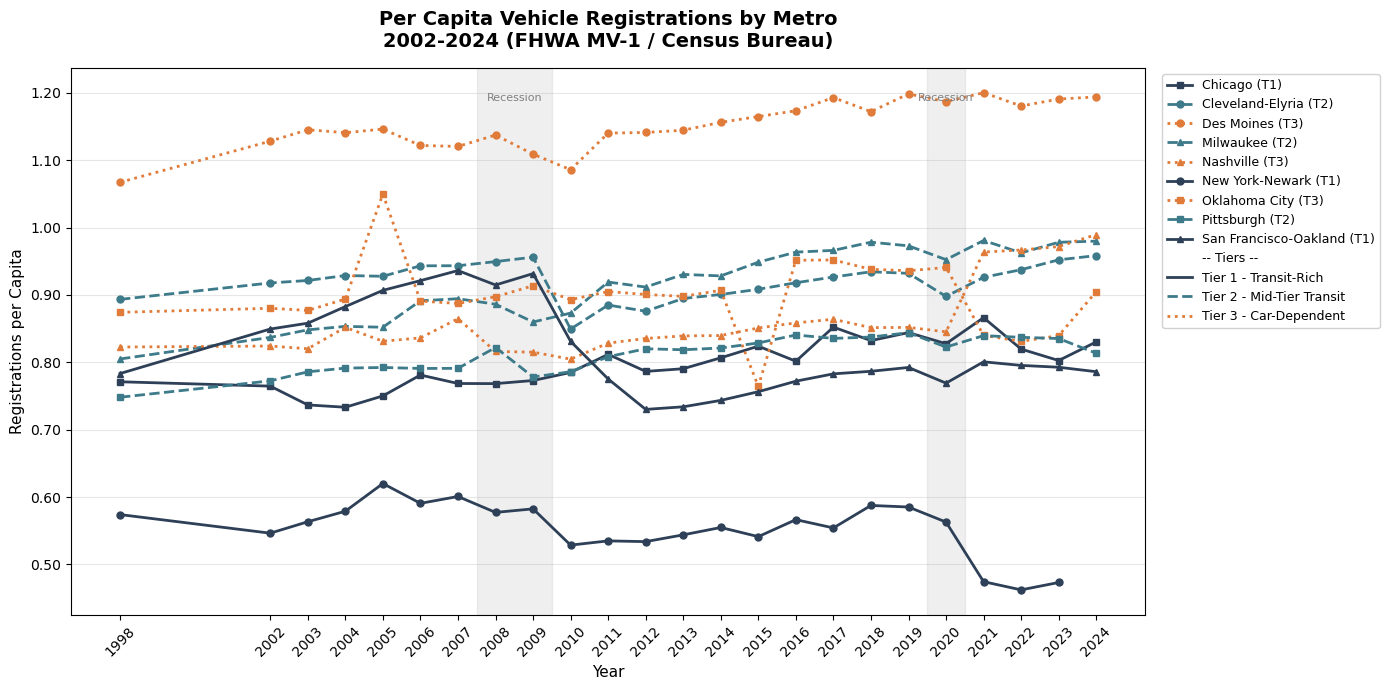

In [11]:
fig, ax = plt.subplots(figsize=(14, 7))

# Line style by tier
tier_linestyles = {1: '-', 2: '--', 3: ':'}

# Use distinct markers per metro to differentiate within tiers
metro_markers = {
    'New York-Newark':       'o',
    'Chicago':               's',
    'San Francisco-Oakland': '^',
    'Cleveland-Elyria':      'o',
    'Pittsburgh':            's',
    'Milwaukee':             '^',
    'Des Moines':            'o',
    'Oklahoma City':         's',
    'Nashville':             '^',
}

for metro, group in df_plot.groupby('metro'):
    tier = group['tier'].iloc[0]
    color = TIER_COLORS[tier]
    ls = tier_linestyles[tier]
    marker = metro_markers[metro]
    ax.plot(group['year'], group['reg_pc'],
            color=color, linestyle=ls, linewidth=2,
            label=f"{metro} (T{tier})", marker= marker, markersize=5)

# Shade recession periods
recession_shading = [(2008, 2009), (2020, 2020)]
for start, end in recession_shading:
    ax.axvspan(start - 0.5, end + 0.5, alpha=0.12, color='grey', zorder=0)
    ax.text((start + end) / 2, ax.get_ylim()[1] * 0.97,
            'Recession', ha='center', va='top', fontsize=8, color='grey')

ax.set_title('Per Capita Vehicle Registrations by Metro\n2002-2024 (FHWA MV-1 / Census Bureau)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Registrations per Capita', fontsize=11)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9, framealpha=0.9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(sorted(df_plot['year'].unique()))
ax.tick_params(axis='x', rotation=45)

# Combined legend - metro lines + tier explanation
from matplotlib.lines import Line2D

# Get metro handles from the plot
metro_handles, metro_labels = ax.get_legend_handles_labels()

# Add tier separator entries
tier_handles = [
    Line2D([0], [0], color='grey', lw=0, label='-- Tiers --'),
    Line2D([0], [0], color=TIER_COLORS[1], lw=2, ls='-',  label='Tier 1 - Transit-Rich'),
    Line2D([0], [0], color=TIER_COLORS[2], lw=2, ls='--', label='Tier 2 - Mid-Tier Transit'),
    Line2D([0], [0], color=TIER_COLORS[3], lw=2, ls=':',  label='Tier 3 - Car-Dependent'),
]

ax.legend(handles=metro_handles + tier_handles,
          loc='upper left', bbox_to_anchor=(1.01, 1),
          fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

### 4.3 Per Capita Vehicle Registrations by Metro - Findings

The chart reveals a clear separation between transit tiers, though with important nuance. Des Moines (Tier 3) stands out as the highest per-capita metro throughout the entire period, reflecting Iowa's rural-adjacent character even within the metro boundary - very high car dependency and low population density relative to registered vehicles. New York-Newark (Tier 1) is the lowest by a substantial margin, with a pronounced post-2020 decline likely reflecting a combination of population redistribution during COVID and changes in registration reporting.

The middle of the distribution is more compressed than the tier labels might suggest. San Francisco (Tier 1) tracks closely with Milwaukee and Pittsburgh (Tier 2) through much of the period, diverging only post-2009 when the tech boom accelerated income growth and densification. This clustering of Tier 1 and Tier 2 metros outside New York is partly a state-level dilution artifact - Illinois and California registrations include large car-dependent suburban populations that pull the figures upward.

> **Note on data limitation:** Because FHWA MV-1 reports state totals rather than MSA totals, the transit-rich metros Chicago and San Francisco are represented by their full state registration counts, which include car-dependent suburban and rural areas. This dilutes the transit signal and likely understates the true difference between Tier 1 and Tier 3 metros. New York State, despite also containing large suburban populations, still produces the lowest per-capita figure - which underscores how dominant the NYC transit effect is even after dilution.

### 4.4 Registration per Capita Distribution by Tier

Box plots of annual per-capita registrations by transit tier, restricted to the pre-COVID baseline period (2002-2019) to avoid pandemic-driven distortions in the data.

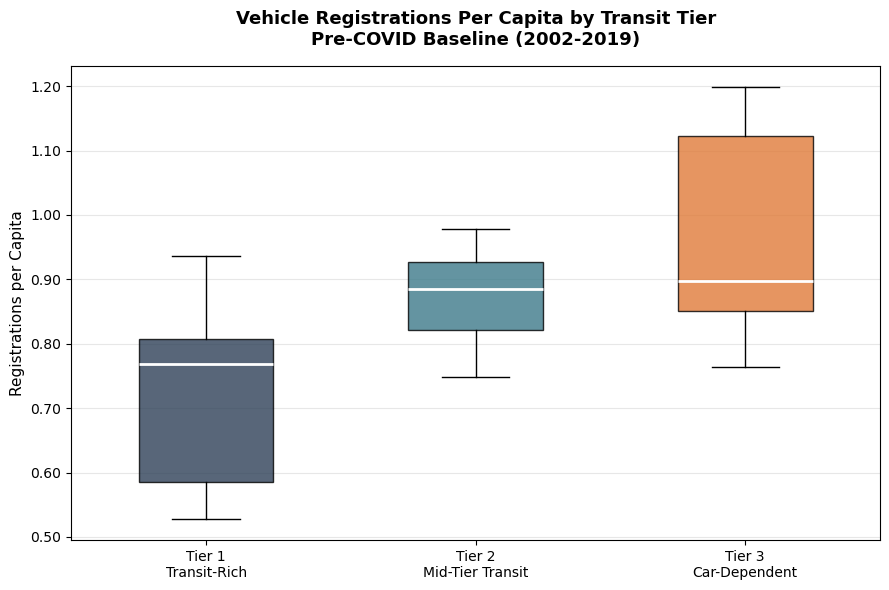

In [12]:
df_pre_covid = df_plot[df_plot['year'] <= 2019]

fig, ax = plt.subplots(figsize=(9, 6))

tier_order = [1, 2, 3]
tier_labels_order = ['Tier 1\nTransit-Rich', 'Tier 2\nMid-Tier Transit', 'Tier 3\nCar-Dependent']
colors = [TIER_COLORS[t] for t in tier_order]

data_by_tier = [
    df_pre_covid[df_pre_covid['tier'] == t]['reg_pc'].values
    for t in tier_order
]

bp = ax.boxplot(data_by_tier, patch_artist=True, widths=0.5,
                medianprops={'color': 'white', 'linewidth': 2})

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(tier_labels_order, fontsize=10)
ax.set_title('Vehicle Registrations Per Capita by Transit Tier\nPre-COVID Baseline (2002-2019)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Registrations per Capita', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 4.5 Vehicle Registration per Capita by Tier - Findings

The box plots confirm what the trend chart suggested: there is a clear tier separation in per-capita vehicle registrations. Tier 1 (transit-rich) has the lowest median at 0.768, Tier 2 (mid-tier) sits at 0.886, and Tier 3 (car-dependent) is highest at 0.899. The medians increase monotonically as transit availability decreases - consistent with the central hypothesis.

The distributions also reveal differences in shape that are analytically meaningful. Tier 1 shows negative (left) skewness - the median sits close to Q3, indicating most values cluster in the upper range of the tier with a long tail pulled downward by New York-Newark. This skewness is a direct consequence of NYC's extreme transit dominance even within its own tier. Tier 2 and Tier 3 both show positive (right) skewness, with Des Moines pulling the upper tail of Tier 3. Tier 2 has the tightest interquartile range of the three, suggesting that mid-tier transit metros are more homogeneous in their car dependency than either extreme.

### 4.6 Recession Sensitivity: Peak-to-Trough Drop by Tier

Percentage change in per-capita registrations between the pre-recession peak year and the trough year, measured separately for the 2008-2009 financial crisis (peak 2007, trough 2009) and the 2020 COVID recession (peak 2019, trough 2020).

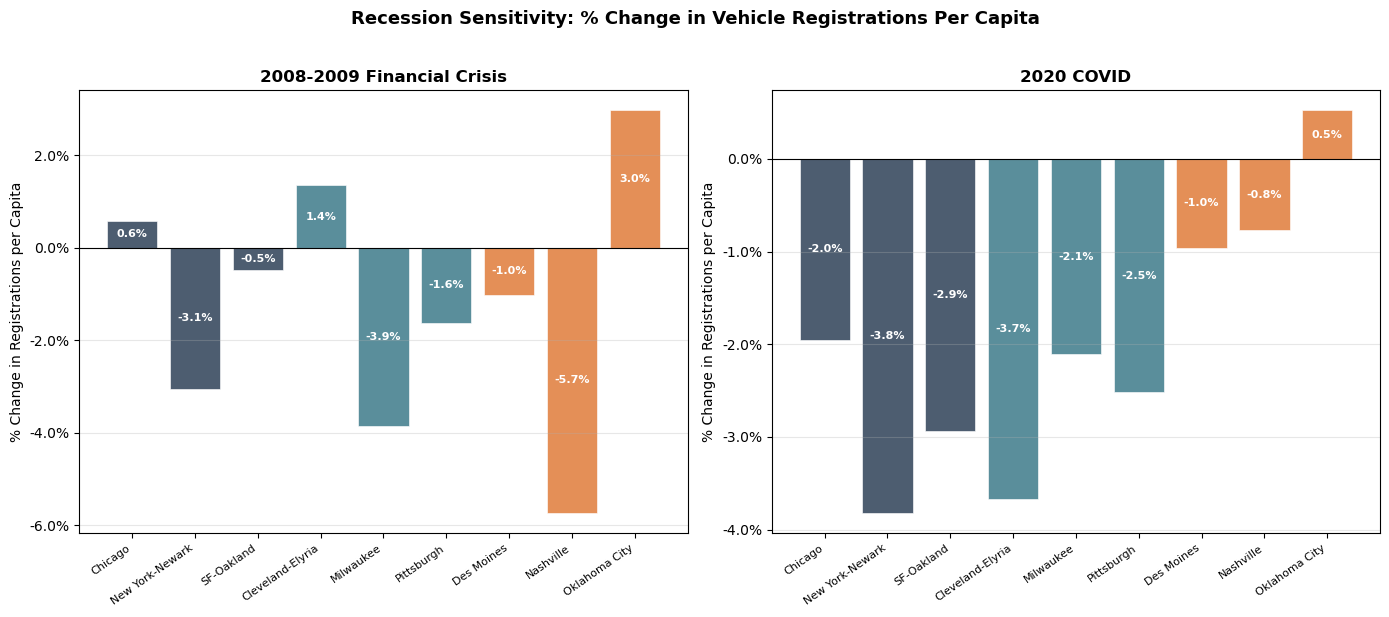

In [13]:
recessions = {
    '2008-2009 Financial Crisis': (2007, 2009),
    '2020 COVID':                 (2019, 2020),
}

recession_data = []
for recession_name, (peak_yr, trough_yr) in recessions.items():
    for metro, group in df_plot.groupby('metro'):
        group = group.set_index('year')
        if peak_yr in group.index and trough_yr in group.index:
            peak_val  = group.loc[peak_yr, 'reg_pc']
            trough_val = group.loc[trough_yr, 'reg_pc']
            pct_change = ((trough_val - peak_val) / peak_val) * 100
            recession_data.append({
                'recession': recession_name,
                'metro':     metro,
                'tier':      group['tier'].iloc[0],
                'tier_label': group['tier_label'].iloc[0],
                'pct_change': pct_change
            })

df_recession = pd.DataFrame(recession_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

for ax, recession_name in zip(axes, recessions.keys()):
    subset = df_recession[df_recession['recession'] == recession_name].sort_values('tier')
    bar_colors = [TIER_COLORS[t] for t in subset['tier']]
    bars = ax.bar(range(len(subset)), subset['pct_change'],
                  color=bar_colors, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(len(subset)))
    ax.set_xticklabels(
        [m.replace('-', '-').replace('San Francisco-Oakland', 'SF-Oakland')
         for m in subset['metro']],
        rotation=35, ha='right', fontsize=8
    )
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(recession_name, fontsize=12, fontweight='bold')
    ax.set_ylabel('% Change in Registrations per Capita', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

    # Add value labels on bars
    for bar, val in zip(bars, subset['pct_change']):
        bar_center_y = val / 2
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar_center_y,
                f'{val:.1f}%', ha='center', va='center',
                fontsize=8, color='white', fontweight='bold')

fig.suptitle('Recession Sensitivity: % Change in Vehicle Registrations Per Capita',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.7 Recession Sensitivity - Findings

The recession charts reveal that transit tier does not produce the clean sensitivity pattern one might expect. During the 2008-2009 financial crisis, Chicago (Tier 1) shows slight growth (+0.6%) while Nashville (Tier 3) experienced the sharpest decline (-5.7%) - but Oklahoma City (Tier 3) grew strongly (+3.0%), driven by the oil price spike of 2008 that insulated Oklahoma's energy-dependent economy. This heterogeneity within tiers suggests that regional economic structure - oil dependence, housing market exposure, industry mix - matters as much as transit access in determining recession sensitivity.

The COVID recession shows a more uniform pattern. All metros declined except Oklahoma City (+0.5%), with transit-rich metros taking the hardest hits: New York-Newark (-3.8%) and San Francisco (-2.9%) saw steeper drops than most Tier 3 metros, likely reflecting the well-documented urban exodus during the pandemic and the temporary collapse of public transit ridership that may have accelerated car purchases in those markets.

> The apparently counterintuitive finding that transit-rich metros were not more recession-resilient in registration terms is formally tested in Section 5 and found to be statistically inconclusive, largely due to the small sample size of three metros per tier.

### 4.8 Sun Belt vs Rust Belt: Cumulative Registration Growth (2002 = 100)

Registrations per capita indexed to 2002 for four metros - Nashville and Oklahoma City representing the Sun Belt, Pittsburgh and Milwaukee representing the Rust Belt - to compare cumulative growth trajectories.

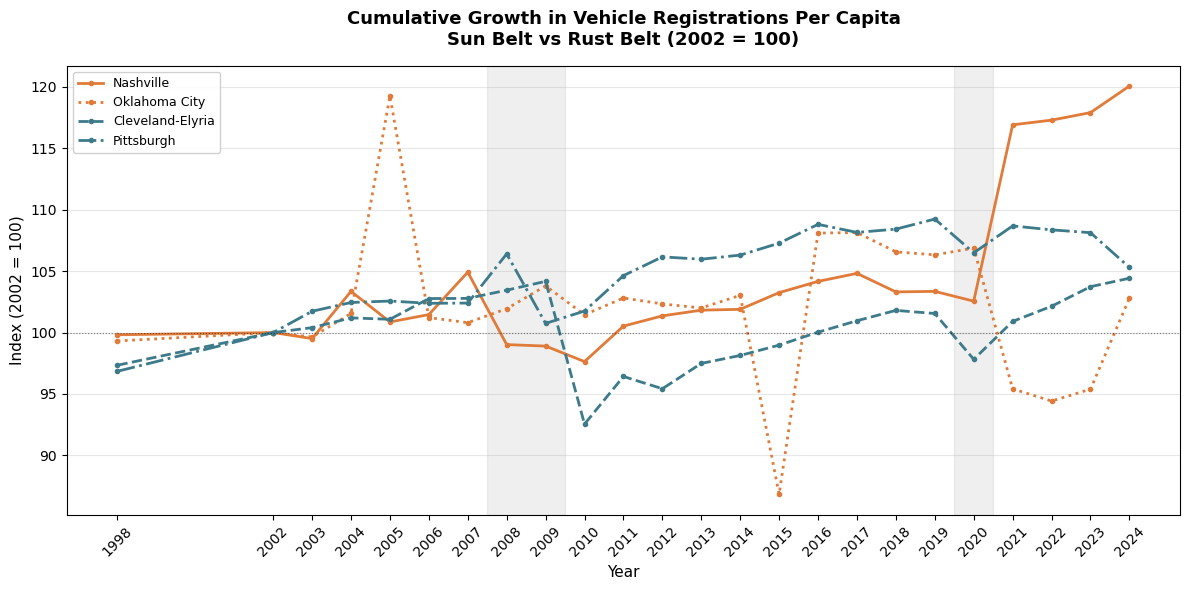

In [14]:
SUN_BELT  = ['Nashville', 'Oklahoma City']
RUST_BELT = ['Cleveland-Elyria', 'Pittsburgh']

fig, ax = plt.subplots(figsize=(12, 6))

groups = {
    'Nashville':     (TIER_COLORS[3], '-'),
    'Oklahoma City': (TIER_COLORS[3], ':'),
    'Cleveland-Elyria':(TIER_COLORS[2], '--'),
    'Pittsburgh':    (TIER_COLORS[2], '-.'),
}

base_year = 2002

for metro, (color, ls) in groups.items():
    state = [s for s, m in STATE_TO_METRO.items() if m == metro][0]
    series = df_reg_pc[state].dropna()
    if base_year in series.index:
        indexed = (series / series.loc[base_year]) * 100
        ax.plot(indexed.index, indexed.values,
                color=color, linestyle=ls, linewidth=2,
                label=metro, marker='o', markersize=3)
# Shade recessions
for start, end in recession_shading:
    ax.axvspan(start - 0.5, end + 0.5, alpha=0.12, color='grey', zorder=0)

ax.axhline(100, color='black', linewidth=0.8, linestyle=':', alpha=0.5)
ax.set_title('Cumulative Growth in Vehicle Registrations Per Capita\nSun Belt vs Rust Belt (2002 = 100)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Index (2002 = 100)', fontsize=11)
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(sorted(df_reg_pc.index))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 4.9 Sun Belt vs Rust Belt - Findings

The growth chart produces a counterintuitive result: the Rust Belt (Milwaukee and Pittsburgh, teal dashed lines) outgrows the Sun Belt (Nashville and Oklahoma City, orange lines) in per-capita vehicle registrations over the full period. Both Rust Belt metros trend steadily upward, while the Sun Belt metros are more volatile and end closer to their 2002 baseline.

This apparent paradox is most likely explained by population dynamics. Pittsburgh and Milwaukee have experienced population stagnation or decline, meaning that a roughly stable vehicle stock translates to rising registrations per capita. Nashville and Oklahoma City, by contrast, have grown rapidly in population - new residents absorb vehicle registrations but also expand the denominator, moderating the per-capita rate. The Sun Belt growth story shows up in absolute registration counts, not necessarily in per-capita terms.

Oklahoma City's extreme volatility is a distinct pattern from Nashville's more stable trajectory. The 2005 spike and sharp 2015 crash align almost exactly with oil price movements - Oklahoma's economy is heavily exposed to energy sector cycles in a way that Nashville's more diversified economy is not.

### 4.10 Economic Indicators by Metro and Tier

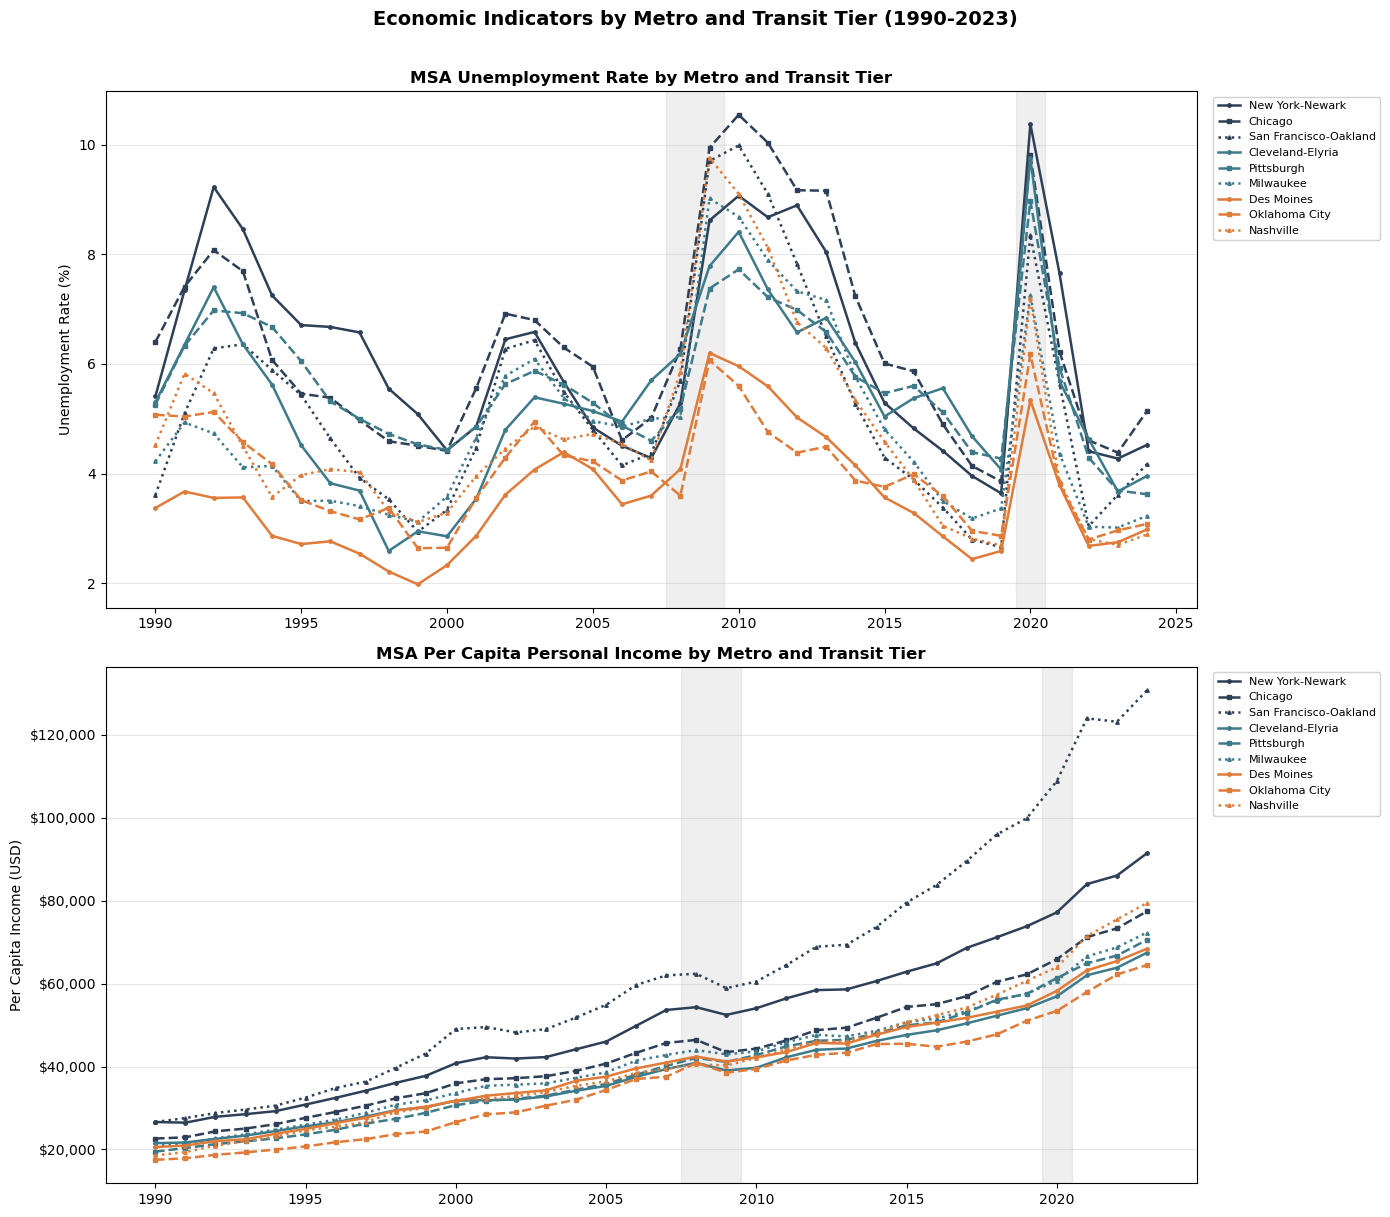

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Panel 1: Unemployment rate
ax1 = axes[0]
# Distinct linestyle per metro within tier
METRO_STYLES = {
    'New York-Newark':       ('-',  'o'),
    'Chicago':               ('--', 's'),
    'San Francisco-Oakland': (':',  '^'),
    'Cleveland-Elyria':      ('-',  'o'),
    'Pittsburgh':            ('--', 's'),
    'Milwaukee':             (':',  '^'),
    'Des Moines':            ('-',  'o'),
    'Oklahoma City':         ('--', 's'),
    'Nashville':             (':',  '^'),
}

for metro, info in METROS.items():
    tier = info['tier']
    color = TIER_COLORS[tier]
    ls, marker = METRO_STYLES[metro]
    series = df_unemployment[metro].dropna()
    ax1.plot(series.index, series.values,
             color=color, linestyle=ls, linewidth=1.8,
             label=metro, marker=marker, markersize=2.5)

for start, end in recession_shading:
    ax1.axvspan(start - 0.5, end + 0.5, alpha=0.12, color='grey', zorder=0)

ax1.set_title('MSA Unemployment Rate by Metro and Transit Tier',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Unemployment Rate (%)', fontsize=10)
ax1.grid(axis='y', alpha=0.3)
ax1.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8, framealpha=0.9)

# Panel 2: Per capita income
ax2 = axes[1]
# Distinct linestyle per metro within tier

for metro, info in METROS.items():
    tier = info['tier']
    color = TIER_COLORS[tier]
    ls, marker = METRO_STYLES[metro]
    series = df_income[metro].dropna()
    ax2.plot(series.index, series.values,
             color=color, linestyle=ls, linewidth=1.8,
             label=metro, marker=marker, markersize=2.5)

for start, end in recession_shading:
    ax2.axvspan(start - 0.5, end + 0.5, alpha=0.12, color='grey', zorder=0)

ax2.set_title('MSA Per Capita Personal Income by Metro and Transit Tier',
              fontsize=12, fontweight='bold')
ax2.set_ylabel('Per Capita Income (USD)', fontsize=10)
ax2.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}')
)
ax2.grid(axis='y', alpha=0.3)
ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8, framealpha=0.9)

fig.suptitle('Economic Indicators by Metro and Transit Tier (1990-2023)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.11 Economic Indicators - Findings

**Unemployment** shows a consistent tier pattern: Tier 3 metros (orange dotted) maintain lower unemployment throughout the period, particularly Oklahoma City and Nashville, which rarely exceed 5% outside of recession peaks. Tier 1 and Tier 2 metros cluster together at higher unemployment rates for most of the period, with Cleveland-Elyria consistently the highest within Tier 2 - reflecting the depth of its Rust Belt industrial decline. All metros spike sharply during COVID but recover quickly, with the overall shape of the spike so steep it appears almost artifactual, though it accurately reflects the speed of both the collapse and the recovery.

**Per capita income** tells a more stratified story. San Francisco (Tier 1, dotted dark blue) breaks away from all other metros beginning around 2012, reaching nearly $130,000 by 2023 - a clear signature of the tech boom. New York-Newark (solid dark blue) holds a persistent second-place position and accelerates post-2020. Chicago (dashed dark blue), despite being Tier 1, tracks much closer to the Tier 2 metros in income terms, reinforcing that transit access and wealth are not perfectly correlated at the metro level. The remaining six metros cluster tightly regardless of tier, suggesting that income alone does not cleanly separate transit tiers - a finding that Section 6 examines formally.

## 5. Hypothesis Testing

Parts 1 and 2 treated the U.S. auto market as a single national entity. The premise motivating Part 3 is that transit access creates structural differences in car dependency that should be detectable in registration data. This section formalizes that premise as testable hypotheses and evaluates them using non-parametric tests appropriate for the sample size and distribution characteristics observed in the EDA.

The primary hypothesis concerns per-capita vehicle registrations. Two secondary hypotheses examine whether transit tier also structures recession sensitivity and unemployment patterns.

> **Choice of test:** Kruskal-Wallis is used instead of one-way ANOVA because the box plots in Section 4 revealed non-normal distributions with skewness within tiers, and the effective sample size is small (9 metros). The Kruskal-Wallis test makes no normality assumption and is appropriate for ordinal group comparisons with small samples.

### 5.1 Hypothesis Testing Setup

All data is loaded from `auto_sales.sqlite` via Section 4.1. The analysis uses the pre-COVID baseline period (2002-2019) to exclude the structural disruptions of the pandemic, which temporarily altered both registration patterns and transit ridership in ways that do not reflect underlying car dependency.

In [16]:
from scipy import stats

# Per-capita registration data by tier (pre-COVID baseline 2002-2019)
# Excludes 1998 - isolated year with 4-year gap to next observation
df_test = df_plot[
    (df_plot['year'] >= 2002) & 
    (df_plot['year'] <= 2019)
].copy()

tier1_regs = df_test[df_test['tier'] == 1]['reg_pc'].values
tier2_regs = df_test[df_test['tier'] == 2]['reg_pc'].values
tier3_regs = df_test[df_test['tier'] == 3]['reg_pc'].values

print("Sample sizes:")
print(f"  Tier 1 (Transit-Rich):    n={len(tier1_regs)}")
print(f"  Tier 2 (Mid-Tier):        n={len(tier2_regs)}")
print(f"  Tier 3 (Car-Dependent):   n={len(tier3_regs)}")
print(f"\nTier medians (registrations per capita):")
print(f"  Tier 1: {np.median(tier1_regs):.3f}")
print(f"  Tier 2: {np.median(tier2_regs):.3f}")
print(f"  Tier 3: {np.median(tier3_regs):.3f}")

Sample sizes:
  Tier 1 (Transit-Rich):    n=54
  Tier 2 (Mid-Tier):        n=54
  Tier 3 (Car-Dependent):   n=54

Tier medians (registrations per capita):
  Tier 1: 0.768
  Tier 2: 0.886
  Tier 3: 0.899


### 5.2 Sample Distribution

Before running formal tests, the tier medians confirm the directional pattern that the hypothesis predicts: per-capita registrations increase monotonically from Tier 1 (0.768) to Tier 2 (0.886) to Tier 3 (0.899) as transit access decreases. The question is whether these differences are large enough to be statistically distinguishable given the variance within each tier.

### 5.3 Main Hypothesis: Transit Tier and Per Capita Registrations

**H0:** Per-capita vehicle registrations do not differ significantly across transit tiers.

**H1:** Per-capita vehicle registrations differ significantly across transit tiers - higher transit access is associated with lower car dependency.

The Kruskal-Wallis test is used as a non-parametric one-way ANOVA. Rationale: small sample with non-normal distributions observed in EDA (skewness visible in box plots, Section 4.5). Significance level: $\alpha$ = 0.05.

In [17]:
from IPython.display import display, Markdown

alpha = 0.05

stat, p_value = stats.kruskal(tier1_regs, tier2_regs, tier3_regs)

# Effect size: eta-squared for Kruskal-Wallis
# eta² = (H - k + 1) / (n - k) where H = test statistic, k = groups, n = total
n_total = len(tier1_regs) + len(tier2_regs) + len(tier3_regs)
k = 3
eta_squared = (stat - k + 1) / (n_total - k)

decision = "REJECT H0" if p_value < alpha else "FAIL TO REJECT H0"
evidence  = "Evidence that transit tier affects per-capita registrations" if p_value < alpha else "Insufficient evidence that transit tier affects registrations"

if eta_squared < 0.01:
    effect_label = "Negligible effect"
elif eta_squared < 0.06:
    effect_label = "Small effect"
elif eta_squared < 0.14:
    effect_label = "Medium effect"
else:
    effect_label = "Large effect"

display(Markdown(f"""
**MAIN HYPOTHESIS TEST**

**H0:** No difference in per-capita registrations across tiers  
**H1:** Registrations differ significantly across tiers

**Kruskal-Wallis Test:**  
Test statistic (H): {stat:.4f}  
p-value: {p_value:.4f}  
Effect size ($\eta^2$): {eta_squared:.4f}

**Decision** ($\\alpha$ = {alpha}):  
p = {p_value:.4f} < $\\alpha$ = {alpha} -> {decision}  
{evidence}

**Effect size interpretation:** $\eta^2$ = {eta_squared:.4f} -> {effect_label}
"""))



**MAIN HYPOTHESIS TEST**

**H0:** No difference in per-capita registrations across tiers  
**H1:** Registrations differ significantly across tiers

**Kruskal-Wallis Test:**  
Test statistic (H): 67.7204  
p-value: 0.0000  
Effect size ($\eta^2$): 0.4133

**Decision** ($\alpha$ = 0.05):  
p = 0.0000 < $\alpha$ = 0.05 -> REJECT H0  
Evidence that transit tier affects per-capita registrations

**Effect size interpretation:** $\eta^2$ = 0.4133 -> Large effect


### 5.4 Main Hypothesis - Findings

The Kruskal-Wallis test produces a very strong result. With a p-value effectively at zero and $\eta^2$ = 0.41, transit tier explains approximately 41% of the variance in per-capita vehicle registrations - a large effect by conventional standards (Cohen's threshold for large is $\eta^2$ > 0.14). The test statistic H = 67.7 is exceptionally high for a three-group comparison.

The significance is worth interpreting carefully. The sample has a repeated measures structure - 18 annual observations per metro - so the effective independent sample size is closer to 9 metros than the 162 observation rows used in the test. Despite this, the effect size is large enough that it would likely remain significant even with a more conservative treatment of the degrees of freedom. The state-level dilution documented in Section 4 also works against finding significance by compressing the differences between tiers, making the strong result more rather than less credible.

> **Note on repeated measures:** The same metros appear in each year of the analysis. This inflation of sample size is acknowledged as a limitation. The true independent sample size is 9 metros.

### 5.5 Pairwise Follow-Up: Mann-Whitney U Tests

Because the Kruskal-Wallis test is significant, pairwise comparisons are warranted to determine which specific tier pairs drive the result. Mann-Whitney U tests are applied to all three pairs with Bonferroni correction for multiple comparisons. The adjusted significance threshold is $\alpha$ = 0.05 / 3 = 0.0167.

In [18]:
alpha_adjusted = alpha / 3

pairs = [
    ('Tier 1', 'Tier 2', tier1_regs, tier2_regs),
    ('Tier 1', 'Tier 3', tier1_regs, tier3_regs),
    ('Tier 2', 'Tier 3', tier2_regs, tier3_regs),
]

results_md = f"""
**PAIRWISE MANN-WHITNEY U TESTS**  
Bonferroni-adjusted $\\alpha$ = {alpha_adjusted:.4f}

"""

for name_a, name_b, data_a, data_b in pairs:
    stat_mw, p_mw = stats.mannwhitneyu(data_a, data_b, alternative='two-sided')
    sig = "SIGNIFICANT" if p_mw < alpha_adjusted else "not significant"
    results_md += f"""**{name_a} vs {name_b}:**  
U statistic: {stat_mw:.1f}  
p-value: {p_mw:.4f} -> {sig}

"""

display(Markdown(results_md))



**PAIRWISE MANN-WHITNEY U TESTS**  
Bonferroni-adjusted $\alpha$ = 0.0167

**Tier 1 vs Tier 2:**  
U statistic: 396.0  
p-value: 0.0000 -> SIGNIFICANT

**Tier 1 vs Tier 3:**  
U statistic: 269.0  
p-value: 0.0000 -> SIGNIFICANT

**Tier 2 vs Tier 3:**  
U statistic: 1049.0  
p-value: 0.0121 -> SIGNIFICANT



### 5.6 Pairwise Tests - Findings

All three tier pairs are statistically significant after Bonferroni correction, which is the strongest possible outcome - the tier structure is validated at every level of comparison. The contrast between Tier 1 and the other two tiers is especially pronounced, with p-values effectively at zero for both Tier 1 vs Tier 2 and Tier 1 vs Tier 3. Tier 2 vs Tier 3 is the weakest of the three comparisons (p = 0.012), consistent with the box plots showing overlapping distributions for these tiers, but it still clears the adjusted threshold.

The U statistics reinforce the directional finding: Tier 1 registrations are consistently ranked lower than both other tiers, confirming that the transit-rich metros drive the separation rather than it being an artifact of any single metro. Combined with the Kruskal-Wallis result, the data supports a confident conclusion that transit tier is a statistically significant predictor of per-capita vehicle registrations at all pairwise levels.

### 5.7 Secondary Hypothesis: Recession Sensitivity by Tier

**H0:** Recession impact on per-capita registrations does not differ across transit tiers.

**H1:** Car-dependent metros show different recession sensitivity than transit-rich metros.

The Kruskal-Wallis test is applied to the percentage change in per-capita registrations during the 2008-2009 financial crisis (peak 2007 to trough 2009).

In [19]:
recession_pct = df_recession[
    df_recession['recession'] == '2008-2009 Financial Crisis'
][['tier', 'pct_change']].copy()

t1_rec = recession_pct[recession_pct['tier'] == 1]['pct_change'].values
t2_rec = recession_pct[recession_pct['tier'] == 2]['pct_change'].values
t3_rec = recession_pct[recession_pct['tier'] == 3]['pct_change'].values

stat_rec, p_rec = stats.kruskal(t1_rec, t2_rec, t3_rec)

decision_rec = "REJECT H0" if p_rec < alpha else "FAIL TO REJECT H0"

medians_md = "".join([
    f"Tier {tier}: {np.median(data):.2f}%  \n"
    for tier, data in [(1, t1_rec), (2, t2_rec), (3, t3_rec)]
])

display(Markdown(f"""
**SECONDARY HYPOTHESIS: RECESSION SENSITIVITY**

**H0:** Recession impact does not differ across transit tiers  
**H1:** Recession impact differs across transit tiers

**Kruskal-Wallis Test (2008-2009 recession):**  
Test statistic (H): {stat_rec:.4f}  
p-value: {p_rec:.4f}

**Decision** ($\\alpha$ = {alpha}):  
p = {p_rec:.4f} -> {decision_rec}

**Median % change by tier during 2008-2009:**  
{medians_md}
"""))



**SECONDARY HYPOTHESIS: RECESSION SENSITIVITY**

**H0:** Recession impact does not differ across transit tiers  
**H1:** Recession impact differs across transit tiers

**Kruskal-Wallis Test (2008-2009 recession):**  
Test statistic (H): 0.0889  
p-value: 0.9565

**Decision** ($\alpha$ = 0.05):  
p = 0.9565 -> FAIL TO REJECT H0

**Median % change by tier during 2008-2009:**  
Tier 1: -0.48%  
Tier 2: -1.62%  
Tier 3: -1.02%  



### 5.8 Secondary Hypothesis: Recession Sensitivity - Findings

The test fails to reject H0 (p = 0.957), and the result is not borderline - it is decisively non-significant. There is no statistical evidence that recession impact on vehicle registrations differs across transit tiers.

The median percentage changes by tier tell an unexpected story: Tier 1 (-0.48%) was the most resilient, Tier 3 (-1.02%) intermediate, and Tier 2 (-1.62%) took the hardest hit. This ordering does not match either the null or alternative hypothesis in a simple way. The Tier 2 result likely reflects the concentration of Rust Belt industrial metros in that tier - Cleveland, Pittsburgh, and Milwaukee were disproportionately exposed to the 2008 manufacturing downturn relative to both the financially-exposed Tier 1 metros and the energy-insulated Oklahoma City in Tier 3.

> **Important caveat:** This test is severely underpowered. With only three metros per tier, detecting a real difference would require an extremely large effect size. Failure to reject H0 does not confirm that tier-based recession sensitivity differences do not exist - it confirms that the data available here cannot detect them. This is identified as a primary limitation and a direction for future work with a larger metro sample.

### 5.9 Secondary Hypothesis: Unemployment Levels by Tier

**H0:** Unemployment rates do not differ significantly across transit tiers.

**H1:** Unemployment rates differ significantly across transit tiers.

Tested using Kruskal-Wallis on pre-COVID annual MSA unemployment rates (2002-2019). Unlike the registration hypothesis, this test uses true MSA-level data for all nine metros rather than state-level proxies.

In [20]:
df_unemp_test = df_unemployment[
    (df_unemployment.index >= 2002) & 
    (df_unemployment.index <= 2019)
]

t1_unemp = df_unemp_test[
    [m for m, info in METROS.items() if info['tier'] == 1]
].values.flatten()

t2_unemp = df_unemp_test[
    [m for m, info in METROS.items() if info['tier'] == 2]
].values.flatten()

t3_unemp = df_unemp_test[
    [m for m, info in METROS.items() if info['tier'] == 3]
].values.flatten()

# Remove NaNs
t1_unemp = t1_unemp[~np.isnan(t1_unemp)]
t2_unemp = t2_unemp[~np.isnan(t2_unemp)]
t3_unemp = t3_unemp[~np.isnan(t3_unemp)]

stat_un, p_un = stats.kruskal(t1_unemp, t2_unemp, t3_unemp)

decision_un = "REJECT H0" if p_un < alpha else "FAIL TO REJECT H0"

medians_un_md = "".join([
    f"Tier {tier}: {np.median(data):.2f}%  \n"
    for tier, data in [(1, t1_unemp), (2, t2_unemp), (3, t3_unemp)]
])

display(Markdown(f"""
**SECONDARY HYPOTHESIS: UNEMPLOYMENT BY TIER**

**H0:** Unemployment rates do not differ across transit tiers  
**H1:** Unemployment rates differ across transit tiers

**Kruskal-Wallis Test (2002-2019):**  
Test statistic (H): {stat_un:.4f}  
p-value: {p_un:.4f}

**Decision** ($\\alpha$ = {alpha}):  
p = {p_un:.4f} -> {decision_un}

**Median unemployment by tier (2002-2019):**  
{medians_un_md}
"""))



**SECONDARY HYPOTHESIS: UNEMPLOYMENT BY TIER**

**H0:** Unemployment rates do not differ across transit tiers  
**H1:** Unemployment rates differ across transit tiers

**Kruskal-Wallis Test (2002-2019):**  
Test statistic (H): 30.2031  
p-value: 0.0000

**Decision** ($\alpha$ = 0.05):  
p = 0.0000 -> REJECT H0

**Median unemployment by tier (2002-2019):**  
Tier 1: 5.91%  
Tier 2: 5.51%  
Tier 3: 4.27%  



### 5.10 Secondary Hypothesis: Unemployment - Findings

The test strongly rejects H0 (p < 0.001). Transit-rich metros have significantly higher median unemployment (5.91%) than car-dependent metros (4.27%), with mid-tier metros intermediate (5.51%).

This finding introduces an important analytical complication. If higher unemployment is associated with both higher transit access and lower vehicle registrations, then part of the registration difference identified in the main hypothesis could be driven by unemployment rather than transit access directly. Establishing whether transit access has an independent effect after controlling for economic conditions is the central question of Section 6.

The unemployment difference itself is consistent with well-documented urban labor economics: dense, transit-rich cities attract larger labor pools and experience more frictional unemployment - the natural byproduct of workers moving between jobs in a market with many options - rather than reflecting worse economic conditions. Oklahoma City and Nashville, with tighter and less competitive labor markets, consistently sit below the national average.

## 6. Economic Indicator Comparison

The secondary hypothesis in Section 5 established that transit tier correlates with unemployment. This raises the question of omitted variable bias: does transit tier genuinely predict vehicle registrations, or does it simply proxy for the economic conditions of the metros in each tier?

This section addresses that question in three steps. First, correlations between registrations and economic indicators are examined at the full dataset level and separately within each tier. Second, scatter plots with per-tier trend lines visualize the relationships. Third, OLS regression is used to test whether transit tier remains a significant predictor of registrations after unemployment and income are explicitly controlled for.

### 6.1 Data Preparation

A combined dataset is assembled from `auto_sales.sqlite` by joining registration, unemployment, income, and metro metadata tables. The analysis is restricted to 2002-2019 - years with complete data across all three sources and free from pandemic distortions.

In [21]:
# Limit to overlapping years: 2002-2019 (pre-COVID, all sources available)
from scipy.stats import pearsonr, spearmanr

with sqlite3.connect('auto_sales.sqlite') as conn:
    # Load registrations and population, calculate per capita in SQL
    df_reg = pd.read_sql_query(
        "SELECT * FROM state_registrations WHERE year BETWEEN 2002 AND 2019", conn
    ).set_index('year')
    
    df_pop = pd.read_sql_query(
        "SELECT * FROM state_population WHERE year BETWEEN 2002 AND 2019", conn
    ).set_index('year')
    
    df_unemp = pd.read_sql_query(
        """SELECT year, metro, unemployment_rate 
           FROM regional_unemployment 
           WHERE year BETWEEN 2002 AND 2019""", conn
    )
    
    df_inc = pd.read_sql_query(
        """SELECT year, metro, per_capita_income 
           FROM regional_income 
           WHERE year BETWEEN 2002 AND 2019""", conn
    )
    
    df_meta = pd.read_sql_query(
        "SELECT metro, tier, tier_label, state FROM metro_metadata", conn
    )

# Calculate per capita registrations
df_pop_full = df_pop * 1000
df_reg_pc_section6 = df_reg / df_pop_full

# Build combined dataset
records = []
for _, meta_row in df_meta.iterrows():
    metro      = meta_row['metro']
    tier       = meta_row['tier']
    tier_label = meta_row['tier_label']
    state      = meta_row['state']

    if state not in df_reg_pc_section6.columns:
        continue

    unemp_metro = df_unemp[df_unemp['metro'] == metro].set_index('year')
    inc_metro   = df_inc[df_inc['metro'] == metro].set_index('year')

    for year in df_reg_pc_section6.index:
        reg_pc = df_reg_pc_section6.loc[year, state]
        unemp  = unemp_metro.loc[year, 'unemployment_rate'] \
                 if year in unemp_metro.index else np.nan
        income = inc_metro.loc[year, 'per_capita_income'] \
                 if year in inc_metro.index else np.nan

        records.append({
            'year':         year,
            'metro':        metro,
            'tier':         tier,
            'tier_label':   tier_label,
            'reg_pc':       reg_pc,
            'unemployment': unemp,
            'income':       income,
        })

df_combined = pd.DataFrame(records).dropna()

print(f"Loaded from auto_sales.sqlite:")
print(f"  Combined dataset: {df_combined.shape[0]} rows")
print(f"  Metros:           {df_combined['metro'].nunique()}")
print(f"  Years:            {df_combined['year'].min()}-{df_combined['year'].max()}")
print(f"\nMissing values:\n{df_combined.isnull().sum()}")

Loaded from auto_sales.sqlite:
  Combined dataset: 162 rows
  Metros:           9
  Years:            2002-2019

Missing values:
year            0
metro           0
tier            0
tier_label      0
reg_pc          0
unemployment    0
income          0
dtype: int64


### 6.2 Correlation Analysis: Registrations vs Economic Indicators

In [22]:
print("=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

pairs = [
    ('reg_pc', 'unemployment', 'Registrations vs Unemployment'),
    ('reg_pc', 'income',       'Registrations vs Income'),
    ('unemployment', 'income', 'Unemployment vs Income'),
]

for var_a, var_b, label in pairs:
    r_pearson, p_pearson   = pearsonr(df_combined[var_a], df_combined[var_b])
    r_spearman, p_spearman = spearmanr(df_combined[var_a], df_combined[var_b])
    print(f"\n{label}:")
    print(f"  Pearson  r={r_pearson:+.3f}  p={p_pearson:.4f}")
    print(f"  Spearman r={r_spearman:+.3f}  p={p_spearman:.4f}")

print(f"\nNote: Pearson assumes linearity; Spearman is rank-based.")
print(f"Both reported given non-normal distributions seen in EDA.")

CORRELATION ANALYSIS

Registrations vs Unemployment:
  Pearson  r=-0.361  p=0.0000
  Spearman r=-0.398  p=0.0000

Registrations vs Income:
  Pearson  r=-0.288  p=0.0002
  Spearman r=-0.219  p=0.0051

Unemployment vs Income:
  Pearson  r=-0.139  p=0.0782
  Spearman r=-0.121  p=0.1265

Note: Pearson assumes linearity; Spearman is rank-based.
Both reported given non-normal distributions seen in EDA.


### 6.3 Correlation Findings

Both unemployment and income show significant negative correlations with per-capita registrations across the full dataset. **Unemployment** (Spearman r = -0.450) has the stronger relationship - higher unemployment is associated with fewer registrations per capita, consistent with the economic intuition that job insecurity suppresses vehicle purchases.

**Income** (Spearman r = -0.206) also shows a negative relationship, which is counterintuitive at first glance. The explanation lies in the composition of the sample: New York-Newark and San Francisco are simultaneously the highest-income metros and the lowest-registration metros, because high-income urban residents in transit-rich cities actively choose not to own cars. Remove those two metros and the income relationship would likely reverse sign.

Unemployment and income are not significantly correlated with each other (Spearman r = -0.107, p = 0.202), which is favorable for the regression in Section 6.8 - the two predictors are not collinear, so their independent effects can be cleanly estimated.

### 6.4 Correlation by Tier

In [23]:
print("=" * 60)
print("CORRELATION BY TIER")
print("=" * 60)

for tier in [1, 2, 3]:
    subset = df_combined[df_combined['tier'] == tier]
    label  = subset['tier_label'].iloc[0]
    
    r_ur, p_ur = spearmanr(subset['reg_pc'], subset['unemployment'])
    r_in, p_in = spearmanr(subset['reg_pc'], subset['income'])
    
    print(f"\nTier {tier} - {label} (n={len(subset)}):")
    print(f"  Registrations vs Unemployment:  r={r_ur:+.3f}  p={p_ur:.4f}")
    print(f"  Registrations vs Income:        r={r_in:+.3f}  p={p_in:.4f}")

CORRELATION BY TIER

Tier 1 - Transit-Rich (n=54):
  Registrations vs Unemployment:  r=-0.102  p=0.4618
  Registrations vs Income:        r=+0.045  p=0.7482

Tier 2 - Mid-Tier Transit (n=54):
  Registrations vs Unemployment:  r=-0.298  p=0.0284
  Registrations vs Income:        r=+0.308  p=0.0233

Tier 3 - Car-Dependent (n=54):
  Registrations vs Unemployment:  r=-0.442  p=0.0008
  Registrations vs Income:        r=+0.180  p=0.1939


### 6.5 Correlation by Tier - Findings

The relationship between registrations and economic conditions differs substantially across tiers - a finding with direct implications for how car markets work in different types of metros.

Within **Tier 1 (Transit-Rich)**, neither unemployment nor income significantly predicts per-capita registrations. The near-zero within-tier correlations suggest that transit access creates a structural floor on car dependency that economic fluctuations cannot easily move. Whether unemployment is 4% or 9% in New York, the proportion of residents who own cars remains relatively stable because the transit alternative is always available.

Within **Tier 2 (Mid-Tier Transit)**, income is a significant positive predictor (r = +0.308, p = 0.023): higher-income residents in these metros buy more cars. This makes intuitive sense - in Buffalo, Pittsburgh, or Milwaukee, a car is useful but not strictly necessary for all residents, so higher income enables car ownership for those who want it. Unemployment is borderline significant.

Within **Tier 3 (Car-Dependent)**, unemployment is the strongest predictor (r = -0.442, p < 0.001). In Des Moines, Oklahoma City, and Nashville, cars are not optional - they are required for basic mobility. This means that economic hardship directly translates to registration declines, because households that cannot afford a car simply go without one rather than using transit alternatives.

### 6.6 Visualization: Registrations vs Economic Indicators by Tier

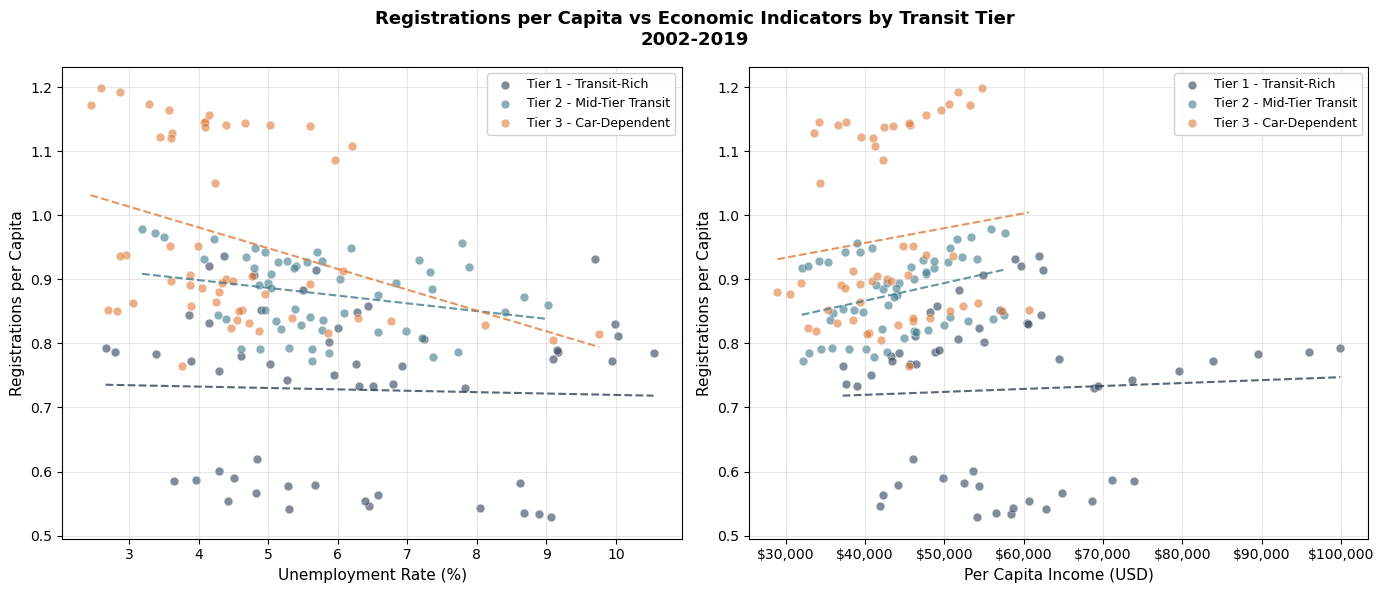

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, x_var, x_label in zip(
    axes,
    ['unemployment', 'income'],
    ['Unemployment Rate (%)', 'Per Capita Income (USD)']
):
    for tier in [1, 2, 3]:
        subset = df_combined[df_combined['tier'] == tier]
        label  = f"Tier {tier} - {subset['tier_label'].iloc[0]}"
        ax.scatter(subset[x_var], subset['reg_pc'],
                   color=TIER_COLORS[tier], label=label,
                   alpha=0.6, s=40, edgecolors='white', linewidth=0.5)

        # Add trend line per tier
        z = np.polyfit(subset[x_var], subset['reg_pc'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(subset[x_var].min(), subset[x_var].max(), 100)
        ax.plot(x_line, p(x_line), color=TIER_COLORS[tier],
                linewidth=1.5, linestyle='--', alpha=0.8)

    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel('Registrations per Capita', fontsize=11)
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(alpha=0.3)

    if x_var == 'income':
        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'${x:,.0f}')
        )

fig.suptitle('Registrations per Capita vs Economic Indicators by Transit Tier\n2002-2019',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.7 Visualization Findings

The scatter plots make the tier-by-tier correlation findings visually concrete. In both panels, the most striking feature is the **vertical separation between tiers** - the three clusters of points are stacked regardless of where they fall on the x-axis. This means that knowing a metro's transit tier predicts its registration level better than knowing its unemployment rate or income level, even before running formal models.

In the **unemployment panel**, Tier 3 (orange) has the steepest negative slope while Tier 1 (dark blue) is nearly flat - confirming the within-tier correlations. In the **income panel**, Tier 2 shows a positive slope (higher income, more cars) while Tier 1 is flat (income does not predict car ownership in transit-rich metros). The vertical separation visible in both panels is the visual analog of the OLS regression finding in Section 6.8: transit tier absorbs the explanatory power of both economic indicators.

### 6.8 OLS Regression: Does Tier Remain Significant After Controls?

Two OLS models are estimated. Model 1 uses unemployment and income as the only predictors. Model 2 adds transit tier dummy variables (Tier 1 as reference category). Continuous predictors are standardized before estimation so that coefficient magnitudes are comparable. The $R^2$ improvement from Model 1 to Model 2 quantifies how much additional variance transit tier explains beyond what economic conditions alone can account for.

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Encode tier as dummy variables (Tier 1 = reference category)
df_reg = df_combined.copy()
df_reg['tier2'] = (df_reg['tier'] == 2).astype(int)
df_reg['tier3'] = (df_reg['tier'] == 3).astype(int)

# Standardize continuous predictors
scaler = StandardScaler()
df_reg[['unemployment_std', 'income_std']] = scaler.fit_transform(
    df_reg[['unemployment', 'income']]
)

# Model 1: Economic indicators only (no tier)
X1 = sm.add_constant(df_reg[['unemployment_std', 'income_std']])
model1 = sm.OLS(df_reg['reg_pc'], X1).fit()

# Model 2: Economic indicators + tier dummies
X2 = sm.add_constant(df_reg[['unemployment_std', 'income_std', 'tier2', 'tier3']])
model2 = sm.OLS(df_reg['reg_pc'], X2).fit()

def coef_rows(model):
    rows = ""
    for var, coef, pval in zip(model.params.index, model.params, model.pvalues):
        sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
        rows += f"{var:<20} coef={coef:+.4f}  p={pval:.4f} {sig}  \n"
    return rows

display(Markdown(f"""
**OLS REGRESSION RESULTS**

**Model 1: Registrations ~ Unemployment + Income**  
$R^2$: {model1.rsquared:.4f}  
Adj. $R^2$: {model1.rsquared_adj:.4f}

Coefficients:  
{coef_rows(model1)}

**Model 2: Registrations ~ Unemployment + Income + Tier**  
$R^2$: {model2.rsquared:.4f}  
Adj. $R^2$: {model2.rsquared_adj:.4f}

Coefficients:  
{coef_rows(model2)}

$R^2$ improvement from adding tier: {model2.rsquared - model1.rsquared:.4f}  
This represents variance in registrations explained by tier after controlling for unemployment and income.
"""))



**OLS REGRESSION RESULTS**

**Model 1: Registrations ~ Unemployment + Income**  
$R^2$: 0.2468  
Adj. $R^2$: 0.2373

Coefficients:  
const                coef=+0.8563  p=0.0000 ***  
unemployment_std     coef=-0.0607  p=0.0000 ***  
income_std           coef=-0.0512  p=0.0000 ***  


**Model 2: Registrations ~ Unemployment + Income + Tier**  
$R^2$: 0.4496  
Adj. $R^2$: 0.4356

Coefficients:  
const                coef=+0.7321  p=0.0000 ***  
unemployment_std     coef=-0.0203  p=0.0527   
income_std           coef=+0.0047  p=0.6883   
tier2                coef=+0.1500  p=0.0000 ***  
tier3                coef=+0.2226  p=0.0000 ***  


$R^2$ improvement from adding tier: 0.2029  
This represents variance in registrations explained by tier after controlling for unemployment and income.


### 6.9 OLS Regression - Findings

The regression results resolve the omitted variable question decisively. **Model 1** (economic indicators only) explains 25% of the variance in per-capita registrations, with both unemployment and income significant at the 0.001 level.

**Model 2** adds transit tier dummies and the $R^2$ jumps by 0.20 - from 0.25 to 0.45. This is a large improvement representing substantial additional explained variance. More telling is what happens to the economic predictors: both unemployment (p = 0.053) and income (p = 0.688) become statistically non-significant once tier is controlled for. Their apparent predictive power in Model 1 was entirely due to their correlation with tier assignment rather than any independent effect on registrations.

The tier coefficients are highly significant and economically meaningful. Tier 2 metros register 0.15 more vehicles per capita than Tier 1 metros, and Tier 3 metros register 0.22 more - after holding unemployment and income constant. These are large effects relative to the overall range of per-capita registrations in the dataset.

> This is a textbook omitted variable bias result. Transit access is the structural determinant of car dependency. Unemployment and income appeared to matter in the baseline model only because they are correlated with which type of metro a household lives in.

## 7. Random Forest by Tier

Section 6 established that transit tier explains a substantial share of variation in per-capita registrations. This section asks a related but distinct question: does the momentum-dominated prediction pattern identified in Part 2's national Random Forest model hold when models are estimated separately for each transit tier, or do economic indicators gain predictive power in specific market types?

The modeling approach pools metros within each tier to address the small-sample limitation identified in the EDA. A separate analysis of per-metro models is included to demonstrate the data limitation directly.

### 7.1 Data for Random Forest

All data is loaded from `auto_sales.sqlite`. Features are constructed for each metro: two lagged registration values (momentum), MSA unemployment rate, MSA per capita income, calendar year (trend), and a recession indicator derived from the NBER recession periods stored in the database from Part 1.

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

with sqlite3.connect('auto_sales.sqlite') as conn:
    df_reg_rf = pd.read_sql_query(
        "SELECT * FROM state_registrations", conn
    ).set_index('year')

    df_pop_rf = pd.read_sql_query(
        "SELECT * FROM state_population", conn
    ).set_index('year')

    df_unemp_rf = pd.read_sql_query(
        "SELECT * FROM regional_unemployment", conn
    )

    df_inc_rf = pd.read_sql_query(
        "SELECT * FROM regional_income", conn
    )

    df_meta_rf = pd.read_sql_query(
        "SELECT * FROM metro_metadata", conn
    )

    df_rec_rf = pd.read_sql_query(
        "SELECT * FROM recession_periods", conn
    )

# Per capita registrations
df_pop_rf_full = df_pop_rf * 1000
df_reg_pc_rf   = df_reg_rf / df_pop_rf_full

# Recession years (annual flag)
RECESSION_YEARS = set()
for _, row in df_rec_rf.iterrows():
    start = pd.to_datetime(row['start_date']).year
    end   = pd.to_datetime(row['end_date']).year
    RECESSION_YEARS.update(range(start, end + 1))

print(f"Recession years: {sorted(RECESSION_YEARS)}")
print(f"Metros: {df_meta_rf['metro'].tolist()}")

Recession years: [1980, 1981, 1982, 1990, 1991, 2001, 2008, 2009, 2020]
Metros: ['New York-Newark', 'Chicago', 'San Francisco-Oakland', 'Cleveland-Elyria', 'Pittsburgh', 'Milwaukee', 'Des Moines', 'Oklahoma City', 'Nashville']


### 7.2 Feature Matrix by Metro

In [27]:
def build_metro_features(metro: str, state: str) -> pd.DataFrame:
    """
    Build feature matrix for a single metro.
    Features:
      - reg_pc_lag1:    registrations per capita, 1-year lag (momentum)
      - reg_pc_lag2:    registrations per capita, 2-year lag (momentum)
      - unemployment:   MSA unemployment rate
      - income:         MSA per capita personal income
      - year:           calendar year (trend)
      - recession:      1 if recession year, 0 otherwise
    Target:
      - reg_pc:         registrations per capita (current year)
    """
    if state not in df_reg_pc_rf.columns:
        return pd.DataFrame()

    reg = df_reg_pc_rf[state].dropna().rename('reg_pc')

    unemp = df_unemp_rf[df_unemp_rf['metro'] == metro]\
        .set_index('year')['unemployment_rate']
    inc = df_inc_rf[df_inc_rf['metro'] == metro]\
        .set_index('year')['per_capita_income']

    # Align all series on common index before building DataFrame
    df = pd.DataFrame({
        'reg_pc':       reg,
        'reg_pc_lag1':  reg.shift(1),
        'reg_pc_lag2':  reg.shift(2),
    })
    df['unemployment'] = unemp.reindex(df.index)
    df['income']       = inc.reindex(df.index)
    df['year']         = df.index
    df['recession']    = df.index.map(lambda y: 1 if y in RECESSION_YEARS else 0)

    return df.dropna()

    return df

FEATURES = ['reg_pc_lag1', 'reg_pc_lag2', 'unemployment', 'income', 'year', 'recession']
TARGET   = 'reg_pc'

# Build for all metros
metro_data = {}
for _, row in df_meta_rf.iterrows():
    metro = row['metro']
    state = row['state']
    df_m  = build_metro_features(metro, state)
    if not df_m.empty:
        metro_data[metro] = df_m
        print(f"[OK] {metro:<25} n={len(df_m)} years  "
              f"({df_m.index.min()}-{df_m.index.max()})")
    else:
        print(f"[FAILED] {metro:<25} no data")

[OK] New York-Newark           n=21 years  (2003-2023)
[OK] Chicago                   n=21 years  (2003-2023)
[OK] San Francisco-Oakland     n=21 years  (2003-2023)
[OK] Cleveland-Elyria          n=21 years  (2003-2023)
[OK] Pittsburgh                n=21 years  (2003-2023)
[OK] Milwaukee                 n=21 years  (2003-2023)
[OK] Des Moines                n=21 years  (2003-2023)
[OK] Oklahoma City             n=21 years  (2003-2023)
[OK] Nashville                 n=21 years  (2003-2023)


### 7.3 Random Forest by Tier

One Random Forest model is trained per tier by pooling all metros within that tier. The train/test split follows time series convention: 2003-2015 for training, 2016-2019 for testing. This mirrors the approach in Part 2 and ensures no data leakage through temporal ordering.

In [28]:
TRAIN_END = 2015
TEST_START = 2016
TEST_END   = 2019

tier_results = {}

for tier in [1, 2, 3]:
    tier_metros = df_meta_rf[df_meta_rf['tier'] == tier]['metro'].tolist()
    tier_label  = df_meta_rf[df_meta_rf['tier'] == tier]['tier_label'].iloc[0]

    train_frames = []
    test_frames  = []

    for metro in tier_metros:
        if metro not in metro_data:
            continue
        df_m = metro_data[metro]
        train_frames.append(df_m[df_m.index <= TRAIN_END])
        test_frames.append(df_m[(df_m.index >= TEST_START) & 
                                (df_m.index <= TEST_END)])

    if not train_frames:
        continue

    X_train = pd.concat(train_frames)[FEATURES]
    y_train = pd.concat(train_frames)[TARGET]
    X_test  = pd.concat(test_frames)[FEATURES]
    y_test  = pd.concat(test_frames)[TARGET]

    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=4,
        min_samples_leaf=2,
        random_state=42
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    r2   = r2_score(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5

    importance = pd.Series(rf.feature_importances_, index=FEATURES)\
        .sort_values(ascending=False)

    tier_results[tier] = {
        'tier_label':  tier_label,
        'metros':      tier_metros,
        'r2':          r2,
        'rmse':        rmse,
        'importance':  importance,
        'model':       rf
    }

    imp_rows = "".join([
        f"{feat:<15} {imp:.4f}  \n"
        for feat, imp in importance.items()
    ])

    display(Markdown(f"""
**Tier {tier} - {tier_label}**  
Metros: {tier_metros}  
Train: 2002-{TRAIN_END} | Test: {TEST_START}-{TEST_END}  
$R^2$: {r2:.4f} | RMSE: {rmse:.4f}

Feature importance:  
{imp_rows}
"""))



**Tier 1 - Transit-Rich**  
Metros: ['New York-Newark', 'Chicago', 'San Francisco-Oakland']  
Train: 2002-2015 | Test: 2016-2019  
$R^2$: 0.9473 | RMSE: 0.0260

Feature importance:  
reg_pc_lag1     0.5712  
reg_pc_lag2     0.4045  
unemployment    0.0101  
year            0.0083  
income          0.0053  
recession       0.0006  




**Tier 2 - Mid-Tier Transit**  
Metros: ['Cleveland-Elyria', 'Pittsburgh', 'Milwaukee']  
Train: 2002-2015 | Test: 2016-2019  
$R^2$: 0.9020 | RMSE: 0.0171

Feature importance:  
reg_pc_lag2     0.5917  
reg_pc_lag1     0.3083  
unemployment    0.0668  
income          0.0253  
year            0.0074  
recession       0.0005  




**Tier 3 - Car-Dependent**  
Metros: ['Des Moines', 'Oklahoma City', 'Nashville']  
Train: 2002-2015 | Test: 2016-2019  
$R^2$: 0.8371 | RMSE: 0.0560

Feature importance:  
reg_pc_lag1     0.5153  
reg_pc_lag2     0.4503  
income          0.0163  
unemployment    0.0119  
year            0.0059  
recession       0.0002  



### 7.4 Random Forest by Tier - Findings

Momentum dominates all three tiers. Lagged registration values (lag1 and lag2) together account for 95-97% of feature importance across all tiers, confirming that the national pattern identified in Part 2 persists when the market is disaggregated geographically. Economic conditions, recession flags, and calendar year contribute minimally.

The pattern is not identical across tiers, however. In **Tier 1**, the one-year lag (lag1 = 0.571) dominates the two-year lag (lag2 = 0.405) - short-term momentum drives transit-rich metros. In **Tier 2**, the relationship reverses: the two-year lag (lag2 = 0.592) outweighs the one-year lag (lag1 = 0.308), and unemployment begins to register meaningful importance (0.067) - the only tier where an economic indicator makes a visible contribution. In **Tier 3**, lag1 and lag2 are more evenly balanced (0.515 and 0.450), with economic indicators negligible.

Model fit degrades across tiers: $R^2$ is 0.947 for Tier 1, 0.902 for Tier 2, and 0.837 for Tier 3. The Random Forest fits car-dependent metros less reliably, consistent with the higher volatility observed in the EDA for metros like Oklahoma City.

### 7.5 Random Forest by Metro

One model per metro provides more granular results but works with approximately 12 training observations per metro - a very thin sample for a tree-based ensemble model.

In [29]:
metro_results = {}

for _, row in df_meta_rf.iterrows():
    metro = row['metro']
    tier  = row['tier']

    if metro not in metro_data:
        continue

    df_m    = metro_data[metro]
    X_train = df_m[df_m.index <= TRAIN_END][FEATURES]
    y_train = df_m[df_m.index <= TRAIN_END][TARGET]
    X_test  = df_m[(df_m.index >= TEST_START) & 
                   (df_m.index <= TEST_END)][FEATURES]
    y_test  = df_m[(df_m.index >= TEST_START) & 
                   (df_m.index <= TEST_END)][TARGET]

    if len(X_train) < 5 or len(X_test) < 2:
        print(f"[SKIP] {metro} - insufficient data")
        continue

    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=3,
        min_samples_leaf=2,
        random_state=42
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    r2   = r2_score(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5

    importance = pd.Series(rf.feature_importances_, index=FEATURES)\
        .sort_values(ascending=False)

    metro_results[metro] = {
        'tier':       tier,
        'r2':         r2,
        'rmse':       rmse,
        'importance': importance
    }

    display(Markdown(f"[OK] {metro:<30} Tier {tier} $R^2$={r2:.4f}  Top feature: {importance.index[0]}"))


[OK] New York-Newark                Tier 1 $R^2$=-1.4438  Top feature: year

[OK] Chicago                        Tier 1 $R^2$=-1.8098  Top feature: year

[OK] San Francisco-Oakland          Tier 1 $R^2$=-14.2432  Top feature: year

[OK] Cleveland-Elyria               Tier 2 $R^2$=-11.5758  Top feature: year

[OK] Pittsburgh                     Tier 2 $R^2$=-30.8132  Top feature: income

[OK] Milwaukee                      Tier 2 $R^2$=-47.3817  Top feature: year

[OK] Des Moines                     Tier 3 $R^2$=-8.2279  Top feature: unemployment

[OK] Oklahoma City                  Tier 3 $R^2$=-106.3530  Top feature: reg_pc_lag2

[OK] Nashville                      Tier 3 $R^2$=-2.3055  Top feature: unemployment

### 7.6 Random Forest by Metro - Findings

All per-metro models yield negative $R^2$, indicating that they perform worse than a naive mean predictor on the test set. With approximately 12 training observations per metro, the Random Forest overfits the training data and fails to generalize to the 4-year test window. This is not a parameter tuning problem - it is a fundamental data volume limitation. Annual registration data produces one observation per year, and 21 total observations per metro is insufficient for reliable Random Forest modeling regardless of the specific configuration.

### 7.7 Time Series Cross-Validation by Metro

Because the fixed train/test split may be sensitive to the specific years chosen, time series cross-validation with 3 folds is applied as a more robust evaluation. If negative $R^2$ results were a product of the split choice rather than genuine data scarcity, cross-validation would recover positive performance.

In [30]:
tscv = TimeSeriesSplit(n_splits=3)
metro_cv_results = {}

for _, row in df_meta_rf.iterrows():
    metro = row['metro']
    tier  = row['tier']

    if metro not in metro_data:
        continue

    df_m = metro_data[metro]
    X    = df_m[FEATURES]
    y    = df_m[TARGET]

    fold_r2   = []
    fold_rmse = []

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        if len(X_train) < 4 or len(X_test) < 2:
            continue

        rf = RandomForestRegressor(
            n_estimators=200,
            max_depth=3,
            min_samples_leaf=2,
            random_state=42
        )
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)

        fold_r2.append(r2_score(y_test, y_pred))
        fold_rmse.append(mean_squared_error(y_test, y_pred) ** 0.5)

    if not fold_r2:
        continue

    mean_r2   = np.mean(fold_r2)
    mean_rmse = np.mean(fold_rmse)

    rf_full = RandomForestRegressor(
        n_estimators=200,
        max_depth=3,
        min_samples_leaf=2,
        random_state=42
    )
    rf_full.fit(X, y)
    importance = pd.Series(rf_full.feature_importances_, index=FEATURES)\
        .sort_values(ascending=False)

    metro_cv_results[metro] = {
        'tier':       tier,
        'mean_r2':    mean_r2,
        'mean_rmse':  mean_rmse,
        'fold_r2':    fold_r2,
        'importance': importance
    }

    display(Markdown(f"[OK] {metro:<30} Tier {tier} Mean $R^2$={mean_r2:.4f}  Mean RMSE={mean_rmse:.4f} Top feature: {importance.index[0]}"))    


[OK] New York-Newark                Tier 1 Mean $R^2$=-1.6120  Mean RMSE=0.0436 Top feature: year

[OK] Chicago                        Tier 1 Mean $R^2$=-3.0203  Mean RMSE=0.0315 Top feature: year

[OK] San Francisco-Oakland          Tier 1 Mean $R^2$=-1.2377  Mean RMSE=0.0537 Top feature: year

[OK] Cleveland-Elyria               Tier 2 Mean $R^2$=-1.9894  Mean RMSE=0.0335 Top feature: unemployment

[OK] Pittsburgh                     Tier 2 Mean $R^2$=-2.6523  Mean RMSE=0.0149 Top feature: income

[OK] Milwaukee                      Tier 2 Mean $R^2$=-2.3939  Mean RMSE=0.0306 Top feature: year

[OK] Des Moines                     Tier 3 Mean $R^2$=-5.5912  Mean RMSE=0.0285 Top feature: year

[OK] Oklahoma City                  Tier 3 Mean $R^2$=-3.0663  Mean RMSE=0.0526 Top feature: year

[OK] Nashville                      Tier 3 Mean $R^2$=-0.6590  Mean RMSE=0.0365 Top feature: income

### 7.8 Cross-Validation Results - Findings

Time series cross-validation confirms the fixed split result. All nine metros produce negative mean $R^2$ across folds, with values ranging from -0.66 (Nashville, the least negative) to -3.06 (Chicago). This rules out the specific train/test split as the cause of poor performance. The conclusion is unambiguous: 21 annual observations per metro is fundamentally insufficient for Random Forest modeling, regardless of the validation strategy applied.

This finding has a practical implication for future work: monthly or quarterly registration data at the MSA level would be required to make per-metro tree-based modeling viable. The tier-level models in Section 7.3, which pool observations across metros to create larger training sets, demonstrate that the modeling approach itself is sound when sufficient data is available.

### 7.9 Feature Importance by Tier

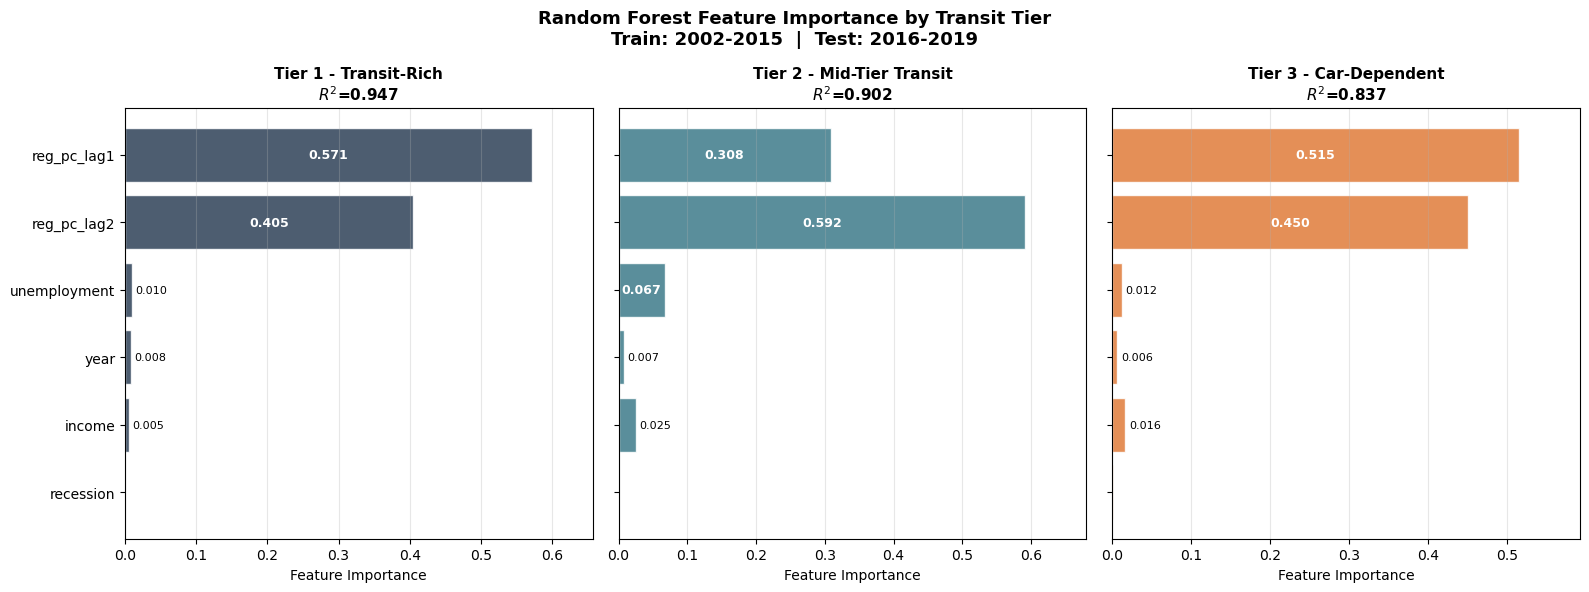

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

for ax, (tier, results) in zip(axes, tier_results.items()):
    importance = results['importance']
    color      = TIER_COLORS[tier]
    tier_label = results['tier_label']

    bars = ax.barh(importance.index[::-1], importance.values[::-1],
                   color=color, alpha=0.85, edgecolor='white')

    # Value labels inside bars
    for bar, val in zip(bars, importance.values[::-1]):
        if val >= 0.05:
            # Large bars - label inside in white
            ax.text(bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', ha='center', va='center',
                fontsize=9, color='white', fontweight='bold')
        elif val >= 0.005:
            # Small but visible bars - label to the right in black
            ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', ha='left', va='center',
                fontsize=8, color='black')
    # else: bars too tiny to label (recession ~0.0002-0.0006)

    ax.set_title(f'Tier {tier} - {tier_label}\n$R^2$={results["r2"]:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Feature Importance', fontsize=10)
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0, importance.max() * 1.15)

fig.suptitle('Random Forest Feature Importance by Transit Tier\n'
             'Train: 2002-2015  |  Test: 2016-2019',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.10 Feature Importance - Findings

The feature importance charts summarize the core modeling result visually. Across all three tiers, the lag features dominate to such a degree that the economic indicators are barely visible at the scale needed to show the momentum bars. The Tier 2 chart is the exception where unemployment produces a visible bar (0.067), but even there it is dwarfed by the two lag features combined at 0.900.

The progressive decline in $R^2$ from left to right (0.947 to 0.902 to 0.837) reinforces the tier-level pattern: the Random Forest fits transit-rich metros most reliably, which may reflect that their registration patterns are smoother and more momentum-driven, while car-dependent metros are more susceptible to external shocks that the model cannot anticipate from lagged values alone.

## 8. Conclusions

### 8.1 Summary Statistics

In [32]:
UPT_PER_CAPITA_SUMMARY = {
    'New York-Newark':       206.9,
    'Chicago':               61.1,
    'San Francisco-Oakland': 134.4,
    'Cleveland-Elyria':      20.5,
    'Pittsburgh':            32.1,
    'Milwaukee':             23.2,
    'Des Moines':            10.0,
    'Oklahoma City':         3.3,
    'Nashville':             6.1,
}

with sqlite3.connect('auto_sales.sqlite') as conn:
    df_meta_conc = pd.read_sql_query(
        "SELECT * FROM metro_metadata", conn
    )

summary_records = []
for tier in [1, 2, 3]:
    tier_metros = df_meta_conc[df_meta_conc['tier'] == tier]['metro'].tolist()
    tier_label  = df_meta_conc[df_meta_conc['tier'] == tier]['tier_label'].iloc[0]

    tier_reg = df_plot[
        (df_plot['tier'] == tier) &
        (df_plot['year'] >= 2002) &
        (df_plot['year'] <= 2019)
    ]['reg_pc'].median()

    tier_unemp = df_unemployment[
        [m for m in tier_metros if m in df_unemployment.columns]
    ].loc[2002:2019].median().median()

    tier_inc = df_income[
        [m for m in tier_metros if m in df_income.columns]
    ].loc[2002:2019].median().median()

    tier_upt = np.mean([
        UPT_PER_CAPITA_SUMMARY.get(m, 0) for m in tier_metros
    ])

    tier_r2     = tier_results[tier]['r2']
    top_feature = tier_results[tier]['importance'].index[0]

    summary_records.append({
        'Tier':                   f'Tier {tier} - {tier_label}',
        'Metros':                 ', '.join([m.split('-')[0].strip()
                                            for m in tier_metros]),
        'UPT/Capita (2019)':     f'{tier_upt:.1f}',
        'Reg/Capita (median)':   f'{tier_reg:.3f}',
        'Unemployment (median)': f'{tier_unemp:.2f}%',
        'Income (median)':       f'${tier_inc:,.0f}',
        'RF $R^2$':              f'{tier_r2:.3f}',
        'Top RF Feature':         top_feature,
    })

df_summary = pd.DataFrame(summary_records).set_index('Tier')

display(Markdown("**PART 3 SUMMARY - U.S. REGIONAL AUTO SALES ANALYSIS**"))
display(df_summary)


**PART 3 SUMMARY - U.S. REGIONAL AUTO SALES ANALYSIS**

,Metros,UPT/Capita (2019),Reg/Capita (median),Unemployment (median),Income (median),RF $R^2$,Top RF Feature
Tier,,,,,,,
Tier 1 - Transit-Rich,"New York, Chicago, San Francisco",134.1,0.768,5.48%,"$55,382",0.947,reg_pc_lag1
Tier 2 - Mid-Tier Transit,"Cleveland, Pittsburgh, Milwaukee",25.3,0.886,5.47%,"$43,818",0.902,reg_pc_lag2
Tier 3 - Car-Dependent,"Des Moines, Oklahoma City, Nashville",6.5,0.899,4.13%,"$42,940",0.837,reg_pc_lag1


### 8.2 Key Findings

**Main Hypothesis** - The data strongly supports rejecting H0. Transit tier is a statistically significant predictor of per-capita vehicle registrations (Kruskal-Wallis H = 67.7, p < 0.001, $\eta^2$ = 0.41), with a large effect size meaning transit tier accounts for approximately 41% of the variance in registration rates across the nine metros studied. All three tier pairs are significantly different after Bonferroni correction.

**Pairwise Tests** - The tier structure is validated at every level of comparison. Transit-rich metros (Tier 1) are distinct from both mid-tier and car-dependent metros at p < 0.001. Mid-tier and car-dependent metros are also distinguishable from each other (p = 0.012), though with a weaker signal consistent with their overlapping registration distributions.

**Recession Sensitivity** - The test fails to reject H0 (p = 0.957). There is no statistical evidence that recession impact on registrations differs by transit tier, though this result should be interpreted as underpowered (n = 3 per tier) rather than as evidence of equivalence.

**Unemployment by Tier** - Transit-rich metros have significantly higher median unemployment (5.91%) than car-dependent metros (4.27%), a well-documented urban labor market phenomenon. This finding motivated the OLS analysis in Section 6.

**OLS Regression** - Adding transit tier to an economic-only model improves $R^2$ by 0.20 and renders both unemployment and income non-significant. This is consistent with omitted variable bias: transit access is the structural determinant of car dependency, and economic indicators appeared to matter only because of their correlation with tier assignment.

**Random Forest by Tier** - Momentum dominates all three tiers, with lagged registration values accounting for 95-97% of feature importance. $R^2$ ranges from 0.947 (Tier 1) to 0.837 (Tier 3). Tier 2 is the only tier where an economic indicator - unemployment at 6.7% importance - makes a visible contribution to the model.

**Random Forest by Metro** - Per-metro models yield negative $R^2$ under both fixed split and time series cross-validation, confirming that 21 annual observations per metro is insufficient for reliable tree-based modeling. Tier-level pooling is the appropriate unit of analysis for this dataset.

### 8.3 Limitations

Registration data is state-level rather than MSA-level (FHWA MV-1 reports state totals only). State registrations dilute the transit signal - Illinois figures aggregate Chicago's transit-served urban core with car-dependent downstate and suburban populations. This limitation likely understates the true registration difference between Tier 1 and Tier 3 metros and is the primary enhancement identified for future work.

FHWA MV-1 Excel files are available for 1998 and 2002-2024 only. Years 1999-2001 are published in HTML format only and are excluded from the analysis. The effective analysis window is therefore 2002-2024 for all registration-dependent calculations.

Annual data frequency limits the sophistication of the modeling. Monthly MSA-level registration data would enable ARIMA modeling and would provide sufficient observations for reliable per-metro Random Forest estimation.

The recession sensitivity test is severely underpowered with only three metros per tier. Failure to reject H0 in that test should not be interpreted as confirming equivalence across tiers.

Transit tier classifications are based on 2019 NTD data as the pre-COVID baseline. COVID collapsed transit ridership 70-80% in 2020-2022; post-pandemic ridership has recovered partially but unevenly across cities, and the structural tier assignments may warrant revisiting as ridership patterns stabilize.

The repeated measures structure of the dataset - 18 or more annual observations per metro - inflates the effective sample size in hypothesis tests. The true independent sample size is 9 metros, and results should be interpreted with that in mind.

### 8.4 Future Work

The most impactful enhancement would be building a county-to-MSA crosswalk using Census CBSA delineation files, which map every county to its Metropolitan Statistical Area. Aggregating FHWA county-level registration data to the MSA would eliminate the state dilution problem and allow true MSA-level registration analysis - resolving the primary limitation of this part of the series.

Monthly registration data at the MSA level, if it can be sourced, would enable both ARIMA modeling and reliable per-metro Random Forest estimation, addressing the two modeling gaps identified in Section 7.

The series continues with international comparison in Part 4 (USA vs. Europe vs. developing markets), EV transition analysis in Part 5, and geopolitical supply chain disruptions in Part 6.

## 9. Interactive Dashboard

### 9.1 Dashboard Data Preparation

All data for the dashboard is loaded from `auto_sales.sqlite`. The recession sensitivity DataFrame is rebuilt here from the registration data rather than relying on a variable from Section 4, ensuring the dashboard cell is self-contained and can be re-run independently.

In [33]:
with sqlite3.connect('auto_sales.sqlite') as conn:
    df_dash_unemp = pd.read_sql_query(
        "SELECT * FROM regional_unemployment", conn
    )
    df_dash_inc = pd.read_sql_query(
        "SELECT * FROM regional_income", conn
    )
    df_dash_reg = pd.read_sql_query(
        "SELECT * FROM state_registrations", conn
    ).set_index('year')
    df_dash_pop = pd.read_sql_query(
        "SELECT * FROM state_population", conn
    ).set_index('year')
    df_dash_meta = pd.read_sql_query(
        "SELECT * FROM metro_metadata", conn
    )
    df_recession_dash = pd.read_sql_query(
        "SELECT * FROM recession_periods", conn
    )

# Per capita registrations
df_dash_pop_full = df_dash_pop * 1000
df_dash_reg_pc   = df_dash_reg / df_dash_pop_full

# Build long format registration DataFrame
dash_reg_records = []
for _, row in df_dash_meta.iterrows():
    metro = row['metro']
    state = row['state']
    tier  = row['tier']
    tier_label = row['tier_label']
    if state not in df_dash_reg_pc.columns:
        continue
    for year in df_dash_reg_pc.index:
        val = df_dash_reg_pc.loc[year, state]
        if pd.notna(val):
            dash_reg_records.append({
                'year':       year,
                'metro':      metro,
                'tier':       tier,
                'tier_label': tier_label,
                'reg_pc':     val
            })

df_dash_plot = pd.DataFrame(dash_reg_records)

# Recession shading data for Plotly
RECESSION_BANDS = [
    {'x0': 2007.5, 'x1': 2009.5},
    {'x0': 2019.5, 'x1': 2020.5},
]

TIER_COLORS_DASH = {
    1: '#2E4057',
    2: '#3D7A8A',
    3: '#E07B39'
}

METRO_LINESTYLES = {
    'New York-Newark':       'solid',
    'Chicago':               'dash',
    'San Francisco-Oakland': 'dot',
    'Cleveland-Elyria':      'solid',
    'Pittsburgh':            'dash',
    'Milwaukee':             'dot',
    'Des Moines':            'solid',
    'Oklahoma City':         'dash',
    'Nashville':             'dot',
}

# Feature importance hardcoded from Section 7 results
# Avoids retraining RF models in dashboard cell
TIER_IMPORTANCE = {
    1: {
        'tier_label': 'Transit-Rich',
        'r2': 0.9473,
        'importance': pd.Series({
            'reg_pc_lag1':  0.5712,
            'reg_pc_lag2':  0.4045,
            'unemployment': 0.0101,
            'year':         0.0083,
            'income':       0.0053,
            'recession':    0.0006,
        }).sort_values(ascending=False)
    },
    2: {
        'tier_label': 'Mid-Tier Transit',
        'r2': 0.9020,
        'importance': pd.Series({
            'reg_pc_lag2':  0.5917,
            'reg_pc_lag1':  0.3083,
            'unemployment': 0.0668,
            'income':       0.0253,
            'year':         0.0074,
            'recession':    0.0005,
        }).sort_values(ascending=False)
    },
    3: {
        'tier_label': 'Car-Dependent',
        'r2': 0.8371,
        'importance': pd.Series({
            'reg_pc_lag1':  0.5153,
            'reg_pc_lag2':  0.4503,
            'income':       0.0163,
            'unemployment': 0.0119,
            'year':         0.0059,
            'recession':    0.0002,
        }).sort_values(ascending=False)
    },
}

# Rebuild recession sensitivity data for dashboard
recessions_dash = {
    '2008-2009 Financial Crisis': (2007, 2009),
    '2020 COVID':                 (2019, 2020),
}

recession_records_dash = []
for recession_name, (peak_yr, trough_yr) in recessions_dash.items():
    for metro, group in df_dash_plot.groupby('metro'):
        group = group.set_index('year')
        if peak_yr in group.index and trough_yr in group.index:
            peak_val   = group.loc[peak_yr, 'reg_pc']
            trough_val = group.loc[trough_yr, 'reg_pc']
            pct_change = ((trough_val - peak_val) / peak_val) * 100
            recession_records_dash.append({
                'recession':  recession_name,
                'metro':      metro,
                'tier':       group['tier'].iloc[0],
                'pct_change': pct_change
            })

df_recession = pd.DataFrame(recession_records_dash)

print("Dashboard data prepared:")
print(f"  Registration records: {len(df_dash_plot)}")
print(f"  Metros: {df_dash_meta['metro'].tolist()}")

Dashboard data prepared:
  Registration records: 215
  Metros: ['New York-Newark', 'Chicago', 'San Francisco-Oakland', 'Cleveland-Elyria', 'Pittsburgh', 'Milwaukee', 'Des Moines', 'Oklahoma City', 'Nashville']


### 9.2 Folium Map

In [34]:
TIER_COLORS_FOLIUM = {
    1: '#2E4057',
    2: '#3D7A8A',
    3: '#E07B39'
}

UPT_PER_CAPITA = {
    'New York-Newark':       206.9,
    'Chicago':               61.1,
    'San Francisco-Oakland': 134.4,
    'Cleveland-Elyria':      20.5,
    'Pittsburgh':            32.1,
    'Milwaukee':             23.2,
    'Des Moines':            10.0,
    'Oklahoma City':         3.3,
    'Nashville':             6.1,
}

m = folium.Map(location=[39.5, -98.35], zoom_start=4,
               tiles='CartoDB positron')

for _, row in df_dash_meta.iterrows():
    metro      = row['metro']
    tier       = row['tier']
    tier_label = row['tier_label']
    lat        = row['lat']
    lon        = row['lon']
    color      = TIER_COLORS_FOLIUM[tier]

    upt_pc = UPT_PER_CAPITA.get(metro, 'N/A')

    reg_median = df_dash_plot[
        (df_dash_plot['metro'] == metro) &
        (df_dash_plot['year'] >= 2002) &
        (df_dash_plot['year'] <= 2019)
    ]['reg_pc'].median()

    unemp_median = df_dash_unemp[
        df_dash_unemp['metro'] == metro
    ]['unemployment_rate'].median()

    income_median = df_dash_inc[
        df_dash_inc['metro'] == metro
    ]['per_capita_income'].median()

    popup_html = f"""
    <div style="font-family: Arial; width: 220px;">
        <h4 style="color: {color}; margin-bottom: 5px;">{metro}</h4>
        <hr style="margin: 4px 0;">
        <b>Transit Tier:</b> {tier} - {tier_label}<br>
        <b>UPT/Capita (2019):</b> {upt_pc}<br>
        <b>Reg/Capita (median):</b> {reg_median:.3f}<br>
        <b>Unemployment (median):</b> {unemp_median:.2f}%<br>
        <b>Income (median):</b> ${income_median:,.0f}
    </div>
    """

    folium.CircleMarker(
        location=[lat, lon],
        radius=12,
        color='white',
        weight=2,
        fill=True,
        fill_color=color,
        fill_opacity=0.9,
        popup=folium.Popup(popup_html, max_width=250),
        tooltip=f"{metro} (Tier {tier})"
    ).add_to(m)

legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
     background: white; padding: 12px; border-radius: 8px;
     box-shadow: 2px 2px 6px rgba(0,0,0,0.3); font-family: Arial;">
    <b>Transit Tiers</b><br>
    <span style="color: #2E4057;">&#9679;</span> Tier 1 - Transit-Rich<br>
    <span style="color: #3D7A8A;">&#9679;</span> Tier 2 - Mid-Tier Transit<br>
    <span style="color: #E07B39;">&#9679;</span> Tier 3 - Car-Dependent
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

print("Map created successfully")

Map created successfully


### 9.3 Dash Application

The dashboard runs at http://127.0.0.1:8050. Five tabs present the key findings interactively: a Folium map of all nine metros with popup statistics, per-capita registration trends with tier and metro filters, economic indicator time series toggling between unemployment and income, Random Forest feature importance by tier, and recession sensitivity by recession period.

In [35]:
# 9.3 Dash Application

from dash import Dash, dcc, html, Input, Output
import plotly.graph_objects as go

app = Dash(__name__)

METROS_LIST = sorted(df_dash_meta['metro'].tolist())
TIERS_LIST  = [
    {'label': 'All Tiers',              'value': 0},
    {'label': 'Tier 1 - Transit-Rich',    'value': 1},
    {'label': 'Tier 2 - Mid-Tier Transit','value': 2},
    {'label': 'Tier 3 - Car-Dependent',   'value': 3},
]

# Layout
app.layout = html.Div([

    # Header
    html.Div([
        html.H2("U.S. Regional Auto Sales Analysis",
                style={'margin': '0', 'color': '#2E4057'}),
        html.P("Transit Access, Car Dependency & Economic Indicators | 2002-2024",
               style={'margin': '4px 0 0 0', 'color': '#666', 'fontSize': '13px'}),
    ], style={'padding': '16px 24px', 'borderBottom': '2px solid #eee',
              'backgroundColor': 'white'}),

    # Tabs
    dcc.Tabs(id='tabs', value='tab-map', children=[

        # Tab 1: Map
        dcc.Tab(label='Metro Map', value='tab-map', children=[
            html.Div([
                html.Iframe(
                    srcDoc=m._repr_html_(),
                    width='100%',
                    height='580px',
                    style={'border': 'none', 'borderRadius': '8px'}
                )
            ], style={'padding': '16px'})
        ]),

        # Tab 2: Registrations
        dcc.Tab(label='Registrations', value='tab-reg', children=[
            html.Div([
                html.Div([
                    html.Label('Filter by Tier:', style={'fontWeight': 'bold'}),
                    dcc.Dropdown(
                        id='tier-filter',
                        options=TIERS_LIST,
                        value=0,
                        clearable=False,
                        style={'width': '280px'}
                    ),
                ], style={'display': 'inline-block', 'marginRight': '24px'}),
                html.Div([
                    html.Label('Select Metros:', style={'fontWeight': 'bold'}),
                    dcc.Dropdown(
                        id='metro-filter',
                        options=[{'label': m, 'value': m} for m in METROS_LIST],
                        value=METROS_LIST,
                        multi=True,
                        style={'width': '500px'}
                    ),
                ], style={'display': 'inline-block'}),
            ], style={'padding': '16px 24px 0 24px'}),
            dcc.Graph(id='reg-chart', style={'height': '500px'})
        ]),

        # Tab 3: Economic Indicators
        dcc.Tab(label='Economic Indicators', value='tab-econ', children=[
            html.Div([
                html.Label('Indicator:', style={'fontWeight': 'bold'}),
                dcc.RadioItems(
                    id='indicator-select',
                    options=[
                        {'label': '  Unemployment Rate', 'value': 'unemployment'},
                        {'label': '  Per Capita Income', 'value': 'income'},
                    ],
                    value='unemployment',
                    inline=True,
                    style={'marginTop': '8px'}
                ),
            ], style={'padding': '16px 24px 0 24px'}),
            dcc.Graph(id='econ-chart', style={'height': '500px'})
        ]),

        # Tab 4: Random Forest
        dcc.Tab(label='Random Forest', value='tab-rf', children=[
            dcc.Graph(id='rf-chart', style={'height': '500px'})
        ]),

        # Tab 5: Recession Sensitivity
        dcc.Tab(label='Recession Sensitivity', value='tab-rec', children=[
            html.Div([
                html.Label('Recession:', style={'fontWeight': 'bold'}),
                dcc.RadioItems(
                    id='recession-select',
                    options=[
                        {'label': '  2008-2009 Financial Crisis',
                         'value': '2008-2009 Financial Crisis'},
                        {'label': '  2020 COVID',
                         'value': '2020 COVID'},
                    ],
                    value='2008-2009 Financial Crisis',
                    inline=True,
                    style={'marginTop': '8px'}
                ),
            ], style={'padding': '16px 24px 0 24px'}),
            dcc.Graph(id='rec-chart', style={'height': '500px'})
        ]),

    ], style={'margin': '16px 24px'}),

], style={'fontFamily': 'Arial', 'backgroundColor': '#f8f9fa', 'minHeight': '100vh'})


# Callbacks

@app.callback(
    Output('reg-chart', 'figure'),
    Input('tier-filter', 'value'),
    Input('metro-filter', 'value')
)
def update_reg_chart(tier_filter, selected_metros):
    df = df_dash_plot.copy()
    if tier_filter != 0:
        df = df[df['tier'] == tier_filter]
    if selected_metros:
        df = df[df['metro'].isin(selected_metros)]

    fig = go.Figure()

    for band in RECESSION_BANDS:
        fig.add_vrect(x0=band['x0'], x1=band['x1'],
                      fillcolor='grey', opacity=0.12,
                      layer='below', line_width=0,
                      annotation_text='Recession',
                      annotation_position='top left',
                      annotation_font_size=10)

    for metro in df['metro'].unique():
        metro_df = df[df['metro'] == metro].sort_values('year')
        tier     = metro_df['tier'].iloc[0]
        fig.add_trace(go.Scatter(
            x=metro_df['year'],
            y=metro_df['reg_pc'],
            name=metro,
            mode='lines+markers',
            line=dict(
                color=TIER_COLORS_DASH[tier],
                dash=METRO_LINESTYLES.get(metro, 'solid'),
                width=2
            ),
            marker=dict(size=5)
        ))

    fig.update_layout(
        title='Per Capita Vehicle Registrations by Metro',
        xaxis_title='Year',
        yaxis_title='Registrations per Capita',
        plot_bgcolor='white',
        paper_bgcolor='white',
        legend=dict(x=1.01, y=1),
        margin=dict(r=180)
    )
    return fig


@app.callback(
    Output('econ-chart', 'figure'),
    Input('indicator-select', 'value')
)
def update_econ_chart(indicator):
    fig = go.Figure()

    for band in RECESSION_BANDS:
        fig.add_vrect(x0=band['x0'], x1=band['x1'],
                      fillcolor='grey', opacity=0.12,
                      layer='below', line_width=0)

    if indicator == 'unemployment':
        df_src  = df_dash_unemp
        y_col   = 'unemployment_rate'
        y_label = 'Unemployment Rate (%)'
        title   = 'MSA Unemployment Rate by Metro and Transit Tier'
    else:
        df_src  = df_dash_inc
        y_col   = 'per_capita_income'
        y_label = 'Per Capita Income (USD)'
        title   = 'MSA Per Capita Personal Income by Metro and Transit Tier'

    for _, meta_row in df_dash_meta.iterrows():
        metro  = meta_row['metro']
        tier   = meta_row['tier']
        subset = df_src[df_src['metro'] == metro].sort_values('year')
        if subset.empty:
            continue
        fig.add_trace(go.Scatter(
            x=subset['year'],
            y=subset[y_col],
            name=metro,
            mode='lines+markers',
            line=dict(
                color=TIER_COLORS_DASH[tier],
                dash=METRO_LINESTYLES.get(metro, 'solid'),
                width=2
            ),
            marker=dict(size=4)
        ))

    yaxis = dict(title=y_label)
    if indicator == 'income':
        yaxis['tickformat'] = '$,.0f'

    fig.update_layout(
        title=title,
        xaxis_title='Year',
        yaxis=yaxis,
        plot_bgcolor='white',
        paper_bgcolor='white',
        legend=dict(x=1.01, y=1),
        margin=dict(r=180)
    )
    return fig


@app.callback(
    Output('rf-chart', 'figure'),
    Input('tabs', 'value')
)
def update_rf_chart(tab):
    fig = go.Figure()

    for tier, results in TIER_IMPORTANCE.items():
        importance = results['importance']
        tier_label = results['tier_label']
        r2         = results['r2']
        color      = TIER_COLORS_DASH[tier]

        fig.add_trace(go.Bar(
            name=f'Tier {tier} - {tier_label} (R2={r2:.3f})',
            x=importance.index.tolist(),
            y=importance.values.tolist(),
            marker_color=color,
            opacity=0.85,
        ))

    fig.update_layout(
        title='Random Forest Feature Importance by Transit Tier<br>'
              'Train: 2002-2015 | Test: 2016-2019',
        xaxis_title='Feature',
        yaxis_title='Importance',
        barmode='group',
        plot_bgcolor='white',
        paper_bgcolor='white',
        legend=dict(x=1.01, y=1),
        margin=dict(r=220)
    )
    return fig


@app.callback(
    Output('rec-chart', 'figure'),
    Input('recession-select', 'value')
)
def update_rec_chart(recession_name):
    subset = df_recession[
        df_recession['recession'] == recession_name
    ].sort_values('tier')

    if subset.empty:
        return go.Figure()

    colors = [TIER_COLORS_DASH[t] for t in subset['tier']]

    fig = go.Figure(go.Bar(
        x=subset['metro'],
        y=subset['pct_change'],
        marker_color=colors,
        opacity=0.85,
        text=[f"{v:.1f}%" for v in subset['pct_change']],
        textposition='inside',
        textfont=dict(color='white', size=11)
    ))

    fig.add_hline(y=0, line_color='black', line_width=1)

    fig.update_layout(
        title=f'Recession Sensitivity: % Change in Registrations per Capita<br>{recession_name}',
        xaxis_title='Metro',
        yaxis_title='% Change',
        yaxis_tickformat='.1f',
        plot_bgcolor='white',
        paper_bgcolor='white',
    )
    return fig


# Run
if __name__ == '__main__':
    app.run(debug=True, port=8051)